## Table of Contents

1.  **[Infrastructure & LLM Setup](#setup)**: Ollama, Llama 3.2, and Google Drive mounting.
2.  **[Dataset Management](#dataset)**: Loading embeddings and news data from Drive.
3.  **[Knowledge Graph Integration](#kg)**: PyKEEN (RotatE) model loading and entity mapping.
4.  **[Query & NER Module](#ner)**: Input query processing and Named Entity Recognition using BNLP.
5.  **[Hybrid Search Engine](#search)**:
    *   Semantic Search (BGE-M3)
    *   Keyword Search (BM25)
    *   Domain/Sub-Domain Aware Filtering & Boosting
6.  **[Advanced Reranking Pipeline](#reranking)**: Cross-Encoder (BGE-Reranker-v2) for precision.
7.  **[Summarization Engine](#summary)**: mT5 Multilingual Summarization.
8.  **[Evaluation & Diagnostics](#eval)**: Similarity distribution and threshold analysis.

In [ ]:
# !pip install colab-xterm
# %load_ext colabxterm
# %xterm

<a name="setup"></a>
### 1. Infrastructure & LLM Setup

In [ ]:
import time
import os
os.environ['OLLAMA_KEEP_ALIVE'] = '-1'

!curl -fsSL https://ollama.com/install.sh | sh
!nohup ollama serve &
time.sleep(15) # Give Ollama server more time to start
!ollama pull llama3.2:3b
!ollama pull llama3.1:8b
!ollama pull qwen2.5:14b
!ollama pull bge-m3
#!ollama run  llama3.2:3b # llama3.2 ollama run llama3.2:3b

>>> Installing ollama to /usr/local
ERROR: This version requires zstd for extraction. Please install zstd and try again:
  - Debian/Ubuntu: sudo apt-get install zstd
  - RHEL/CentOS/Fedora: sudo dnf install zstd
  - Arch: sudo pacman -S zstd
nohup: appending output to 'nohup.out'
nohup: failed to run command 'ollama': No such file or directory
/bin/bash: line 1: ollama: command not found
/bin/bash: line 1: ollama: command not found
/bin/bash: line 1: ollama: command not found
/bin/bash: line 1: ollama: command not found


In [ ]:
!pip install requests

In [ ]:
!pip install ollama

### Correctly Save Ollama Models to Google Drive

To ensure Ollama models are saved to your Google Drive for persistence, you must set the `OLLAMA_MODELS` environment variable *before* pulling the models. We will first stop any running Ollama processes, set the environment variable, and then re-pull the `bge-m3` model.

In [ ]:
# 1. Stop any running Ollama processes to prevent 'address already in use' errors
!kill $(lsof -t -i:11434)

!sudo apt-get install zstd -y
!curl -fsSL https://ollama.com/install.sh | sh

import os
os.environ['OLLAMA_KEEP_ALIVE'] = '-1'   # ← add this
!nohup ollama serve &

import time
time.sleep(15)

kill: usage: kill [-s sigspec | -n signum | -sigspec] pid | jobspec ... or kill -l [sigspec]
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 52 not upgraded.
Need to get 644 kB of archives.
After this operation, 1,845 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 zstd amd64 1.5.5+dfsg2-2build1.1 [644 kB]
Fetched 644 kB in 2s (422 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 

Now, the `bge-m3` model should be stored within the `ollama_models` folder in your Google Drive. This means if your Colab runtime disconnects, the model won't need to be re-downloaded next time you connect and set up the `OLLAMA_MODELS` environment variable correctly.

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True) # Remount to ensure proper permissions if needed

# Define the path in your Google Drive where models will be stored
ollama_models_path = '/content/drive/MyDrive/ollama_models/Bge-m3'
os.environ['OLLAMA_MODELS'] = ollama_models_path

# Create the directory in Drive if it doesn't exist
!mkdir -p "{ollama_models_path}"

print(f"OLLAMA_MODELS environment variable set to: {os.environ['OLLAMA_MODELS']}")
print(f"Created or ensured directory: {ollama_models_path}")

Mounted at /content/drive
OLLAMA_MODELS environment variable set to: /content/drive/MyDrive/ollama_models/Bge-m3
Created or ensured directory: /content/drive/MyDrive/ollama_models/Bge-m3


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True) # Remount to ensure proper permissions if needed

# Define the path in your Google Drive where models will be stored
ollama_models_llama3b_path = '/content/drive/MyDrive/ollama_models/LLama3.2'
os.environ['OLLAMA_MODELS'] = ollama_models_llama3b_path

# Create the directory in Drive if it doesn't exist
!mkdir -p "{ollama_models_llama3b_path}"

print(f"OLLAMA_MODELS environment variable set to: {os.environ['OLLAMA_MODELS']}")
print(f"Created or ensured directory: {ollama_models_llama3b_path}")

Mounted at /content/drive
OLLAMA_MODELS environment variable set to: /content/drive/MyDrive/ollama_models/LLama3.2
Created or ensured directory: /content/drive/MyDrive/ollama_models/LLama3.2


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True) # Remount to ensure proper permissions if needed

# Define the path in your Google Drive where models will be stored
ollama_models_llama8b_path ='/content/drive/MyDrive/llama3.1:8b'
os.environ['OLLAMA_MODELS'] = ollama_models_llama8b_path

# Create the directory in Drive if it doesn't exist
!mkdir -p "{ollama_models_llama3b_path}"

print(f"OLLAMA_MODELS environment variable set to: {os.environ['OLLAMA_MODELS']}")
print(f"Created or ensured directory: {ollama_models_llama8b_path}")

Mounted at /content/drive
OLLAMA_MODELS environment variable set to: /content/drive/MyDrive/llama3.1:8b
Created or ensured directory: /content/drive/MyDrive/llama3.1:8b


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True) # Remount to ensure proper permissions if needed

# Define the path in your Google Drive where models will be stored
ollama_models_qwen14b_path = '/content/drive/MyDrive/ollama_models/qwen2.5:14b'
os.environ['OLLAMA_MODELS'] = ollama_models_qwen14b_path

# Create the directory in Drive if it doesn't exist
!mkdir -p "{ollama_models_llama3b_path}"

print(f"OLLAMA_MODELS environment variable set to: {os.environ['OLLAMA_MODELS']}")
print(f"Created or ensured directory: {ollama_models_qwen14b_path}")

Mounted at /content/drive
OLLAMA_MODELS environment variable set to: /content/drive/MyDrive/ollama_models/qwen2.5:14b
Created or ensured directory: /content/drive/MyDrive/ollama_models/qwen2.5:14b


In [ ]:
# 2. Install zstd (required for Ollama extraction), then Ollama binary, restart Ollama server, and pull the model.
!sudo apt-get install zstd -y
!curl -fsSL https://ollama.com/install.sh | sh

import os
os.environ['OLLAMA_KEEP_ALIVE'] = '-1'

!nohup ollama serve &

import time
time.sleep(15) # Give Ollama server time to start

print("Ollama server restarted.")

# 3. Pull the bge-m3 model. It should now be saved in your Google Drive.
!ollama pull bge-m3
!ollama pull llama3.1:8b
!ollama pull llama3.2:3b

print("bge-m3 model pulled. It should now be saved in your Google Drive at the path specified by OLLAMA_MODELS.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.5.5+dfsg2-2build1.1).
0 upgraded, 0 newly installed, 0 to remove and 52 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
nohup: appending output to 'nohup.out'
Ollama server restarted.



bge-m3 model pulled. It should now be saved in your Google Drive at the path specified by OLLAMA_MODELS.


In [ ]:
import pandas as pd
import json
import ollama # is used for converting text into vector
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install -q transformers==4.41.2 huggingface_hub==0.23.2 accelerate==0.30.1 tokenizers==0.19.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.0/321.0 kB 32.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 145.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 26.7 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)


<a name="dataset"></a>
### 2. Dataset Management

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import ast # For safely evaluating string representations of lists

drive.mount('/content/drive', force_remount=True)

# Define the path to your df_with_embeddings.csv file in Google Drive
drive_path = '/content/drive/MyDrive/Thesis/Datasets/df_with_embeddings.csv' # Adjust this path if your file is in a different location

print(f"Loading data from: {drive_path}")

try:
    # Load the DataFrame with embeddings
    df_loaded = pd.read_csv(drive_path)

    # Convert the string representation of embeddings back to a list of lists
    df_loaded['embeddings'] = df_loaded['embeddings'].apply(ast.literal_eval)

    # Reconstruct the original df (without the embeddings column)
    # Assuming 'embeddings' was added after 'Text' and is not an original column
    df = df_loaded.drop(columns=['embeddings']).copy()

    # Reconstruct the vectors list
    vectors = df_loaded['embeddings'].tolist()

    print("df and vectors successfully loaded and reconstructed from Google Drive.")
    print(f"Original df shape: {df.shape}")
    print(f"Number of vectors: {len(vectors)}")
    display(df.head())
    print("First 5 elements of the first vector:")
    print(vectors[0][:5])

except FileNotFoundError:
    print(f"Error: The file '{drive_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred during loading or reconstruction: {e}")

Mounted at /content/drive
Loading data from: /content/drive/MyDrive/Thesis/Datasets/df_with_embeddings.csv
df and vectors successfully loaded and reconstructed from Google Drive.
Original df shape: (10761, 11)
Number of vectors: 10761


,Language,Text,Translated_Text,Domain,Domain_ID,Translated_Domain,Translated_Domain_ID,Sub-Domain,Sub-Domain_ID,Translated_Sub-Domain,Translated_Sub-Domain_ID
0,en,The terms of the trade agreement between Bangl...,বিশেষ করে স্থানীয় শিল্প ও কৃষকদের স্বার্থ রক্...,Agriculture,3,কৃষি,3,Markets and products,11,বাজার এবং পণ্য,11
1,bn,নড়াইল সদর উপজেলায় পাল্টাপাল্টি হামলায় বাবা-ছেল...,"The killing of four people, including a father...",অপরাধ,1,Crime,1,সহিংস অপরাধ,3,Violent crime,3
2,en,The government has amended the labour law by l...,সরকার ট্রেড ইউনিয়ন গঠনের শর্ত শিথিল করে শ্রম ...,Business,4,ব্যবসা,4,Finance and companies,14,অর্থায়ন এবং কোম্পানি,14
3,bn,সর্বাধুনিক ওএলইডি প্রযুক্তির টিভি সিরিজ নিয়ে এ...,Samsung has brought a TV series with the lates...,ব্যবসা,4,Business,4,অর্থায়ন এবং কোম্পানি,14,Finance and companies,14
4,bn,অপারেশন ডেভিল হান্ট ফেজ-২–এর আওতায় ২৪ ঘণ্টায় র...,Dhaka Metropolitan Police (DMP) has arrested 3...,অপরাধ,1,Crime,1,মাদক ও পাচার,5,Drugs and trafficking,5


First 5 elements of the first vector:
[-0.004954437, -0.03260599, -0.046228062, 0.0142784985, -0.013562873]


#Save Embeddings to a CSV File

Saving to a CSV file is useful for tabular data. Each row will represent an embedding, and each column a dimension. We'll use `pandas` for this.

### Save Embeddings to a DF



In [ ]:
import pandas as pd

# Match the DataFrame rows to the number of generated vectors
df_subset = df.head(len(vectors)).copy()

# Add the embeddings column
df_subset['embeddings'] = vectors

# Reorder columns to place 'embeddings' next to 'Text' for better visibility
cols = list(df_subset.columns)
text_idx = cols.index('Text')
cols.insert(text_idx + 1, cols.pop(cols.index('embeddings')))
df_subset = df_subset[cols]

# Save the combined DataFrame
df_subset.to_csv('df_with_embeddings.csv', index=False)

print(f"Added 'embeddings' column to {len(df_subset)} rows.")
display(df_subset[['Text', 'embeddings','Language','Translated_Text', 'Domain','Domain_ID','Translated_Domain','Translated_Domain_ID' ,'Sub-Domain','Sub-Domain_ID','Translated_Sub-Domain','Translated_Sub-Domain_ID']].head())

Added 'embeddings' column to 10761 rows.


,Text,embeddings,Language,Translated_Text,Domain,Domain_ID,Translated_Domain,Translated_Domain_ID,Sub-Domain,Sub-Domain_ID,Translated_Sub-Domain,Translated_Sub-Domain_ID
0,The terms of the trade agreement between Bangl...,"[-0.004954437, -0.03260599, -0.046228062, 0.01...",en,বিশেষ করে স্থানীয় শিল্প ও কৃষকদের স্বার্থ রক্...,Agriculture,3,কৃষি,3,Markets and products,11,বাজার এবং পণ্য,11
1,নড়াইল সদর উপজেলায় পাল্টাপাল্টি হামলায় বাবা-ছেল...,"[0.0030652299, 0.03232765, -0.03491338, 0.0249...",bn,"The killing of four people, including a father...",অপরাধ,1,Crime,1,সহিংস অপরাধ,3,Violent crime,3
2,The government has amended the labour law by l...,"[-0.0129126245, -0.0072512357, -0.042532638, 0...",en,সরকার ট্রেড ইউনিয়ন গঠনের শর্ত শিথিল করে শ্রম ...,Business,4,ব্যবসা,4,Finance and companies,14,অর্থায়ন এবং কোম্পানি,14
3,সর্বাধুনিক ওএলইডি প্রযুক্তির টিভি সিরিজ নিয়ে এ...,"[-0.06124251, -0.020651039, -0.069620356, -0.0...",bn,Samsung has brought a TV series with the lates...,ব্যবসা,4,Business,4,অর্থায়ন এবং কোম্পানি,14,Finance and companies,14
4,অপারেশন ডেভিল হান্ট ফেজ-২–এর আওতায় ২৪ ঘণ্টায় র...,"[-0.0032239778, 0.0007153621, -0.046007805, 0....",bn,Dhaka Metropolitan Police (DMP) has arrested 3...,অপরাধ,1,Crime,1,মাদক ও পাচার,5,Drugs and trafficking,5


#Saving in a vector Database Of CromeDB

In [ ]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 129.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-api
    Foun

In [ ]:
# import chromadb
# import numpy as np
# import os

# # গুগল ড্রাইভের পাথ যেখানে ডাটাবেস সেভ হবে
# drive_db_path = "/content/drive/MyDrive/Thesis/Datasets/chroma_db"
# os.makedirs(drive_db_path, exist_ok=True)

# # PersistentClient এখন সরাসরি ড্রাইভ পাথ ব্যবহার করবে
# chroma_client = chromadb.PersistentClient(path=drive_db_path)
# collection = chroma_client.get_or_create_collection(name="news_embeddings")

# # Full dataset processing
# data_to_store = df_loaded.copy()
# ids = [str(i) for i in data_to_store.index]
# documents = data_to_store['Text'].astype(str).tolist()

# if isinstance(data_to_store['embeddings'].iloc[0], str):
#     import ast
#     embeddings = data_to_store['embeddings'].apply(ast.literal_eval).tolist()
# else:
#     embeddings = data_to_store['embeddings'].tolist()

# meta_cols = [c for c in data_to_store.columns if c not in ['Text', 'embeddings']]
# meta_df = data_to_store[meta_cols].copy()

# for col in meta_df.columns:
#     if meta_df[col].dtype == object:
#         meta_df[col] = meta_df[col].apply(
#             lambda x: str(x) if isinstance(x, (list, dict)) else x
#         )
#     meta_df[col] = meta_df[col].fillna("")

# metadatas = meta_df.to_dict('records')

# # Batch insertion to Drive path
# BATCH = 2000 # Batch size slightly reduced for stable drive writing
# n = len(ids)
# for i in range(0, n, BATCH):
#     end = min(i + BATCH, n)
#     collection.add(
#         ids=ids[i:end],
#         embeddings=embeddings[i:end],
#         documents=documents[i:end],
#         metadatas=metadatas[i:end]
#     )
#     print(f"Inserted {end}/{n} into Drive-based collection")

# print(f"Total stored in Drive: {collection.count()}")

#Datasets in CromeDB

In [ ]:
from google.colab import drive
import pandas as pd
import chromadb
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# # 2. Load the CSV Dataset
# csv_path = '/content/drive/MyDrive/Thesis/Datasets/df_with_embeddings.csv'
# if os.path.exists(csv_path):
#     df_loaded = pd.read_csv(csv_path)
#     print(f"Successfully loaded CSV from Drive. Shape: {df_loaded.shape}")
#     display(df_loaded.head())
# else:
#     print(f"CSV file not found at: {csv_path}")

# 3. Connect to Persistent ChromaDB
db_path = '/content/drive/MyDrive/Thesis/Datasets/chroma_db'
if os.path.exists(db_path):
    chroma_client = chromadb.PersistentClient(path=db_path)
    collection = chroma_client.get_collection(name='news_embeddings')
    print(f"Connected to ChromaDB collection. Total items: {collection.count()}")
else:
    print(f"ChromaDB directory not found at: {db_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Connected to ChromaDB collection. Total items: 10772


In [ ]:
print(f"DataFrame-এ মোট ডাটা আছে: {len(df_loaded)} টি")
print(f"ChromaDB কালেকশনে মোট ডাটা আছে: {collection.count()} টি")

if len(df_loaded) == collection.count():
    print("\nঅভিনন্দন! আপনার ডেটাসেট এবং ChromaDB ইনডেক্স সম্পূর্ণ এক।")
else:
    print(f"\nসতর্কতা: সংখ্যায় পার্থক্য পাওয়া গেছে! পার্থক্য: {abs(len(df_loaded) - collection.count())} টি।")

DataFrame-এ মোট ডাটা আছে: 10761 টি
ChromaDB কালেকশনে মোট ডাটা আছে: 10772 টি

সতর্কতা: সংখ্যায় পার্থক্য পাওয়া গেছে! পার্থক্য: 11 টি।


### ব্যাখ্যা (Explanation):

আপনার মনে হওয়ার কারণ হতে পারে যে ডেটাসেট এবং ChromaDB ইনডেক্স এক নয়। এর কিছু সম্ভাব্য কারণ নিচে দেওয়া হলো:

১. **আংশিক ইনজেশন (Partial Ingestion):** আপনি যখন ডাটা ChromaDB-তে আপলোড করেছেন (Batch insertion), তখন যদি কোনো কারণে কোডটি মাঝপথে বন্ধ হয়ে যায় বা রানটাইম ডিসকানেক্ট হয়ে যায়, তবে পুরো ১০,৭৬১ টি ডাটা সেভ না-ও হতে পারে।

২. **ডুপ্লিকেট আইডি (Duplicate IDs):** ChromaDB-তে যদি একই আইডি একাধিকবার ব্যবহারের চেষ্টা করা হয়, তবে সেটি ওভাররাইট হয় অথবা নতুন করে অ্যাড হয় না। আপনার সিএসভি ফাইলে যদি ডুপ্লিকেট ইনডেক্স থাকে, তবে ChromaDB-তে আইটেম সংখ্যা কমে যেতে পারে।

৩. **persistent_client পাথ:** আপনি যদি গুগল ড্রাইভের সঠিক ফোল্ডারটি (`/content/drive/MyDrive/Thesis/Datasets/chroma_db`) মাউন্ট না করে বা ভুল পাথে ডাটাবেস ক্রিয়েট করেন, তবে এটি আগের পুরনো বা খালি কোনো কালেকশন দেখাতে পারে।

**যাচাই করার উপায়:** ওপরের কোডটি রান করলে আপনি দেখতে পাবেন বর্তমানে দুই জায়গায় ঠিক কতটি করে রেকর্ড আছে। যদি সংখ্যা মিলে যায়, তবে আপনি নিশ্চিত থাকতে পারেন যে আপনার ইনডেক্সিং সঠিক হয়েছে।

In [ ]:
import pandas as pd

# ChromaDB কালেকশন থেকে ডেটা দেখা (Peeking data)
peek_results = collection.peek(5)

# একটি প্যান্ডাস ডাটাফ্রেমে সাজিয়ে দেখানো
# vec[:5] কে str() দিয়ে রূপান্তর করা হয়েছে যাতে '...' যোগ করা যায়
peek_df = pd.DataFrame({
    'ID': peek_results['ids'],
    'Document Preview': [doc[:150] + '...' for doc in peek_results['documents']],
    'Metadata': peek_results['metadatas'],
    'Embedding Preview': [str(list(vec[:5])) + '...' for vec in peek_results['embeddings']]
})

print(f"কালেকশনে মোট ডেটা আছে: {collection.count()} টি")
display(peek_df)

কালেকশনে মোট ডেটা আছে: 10772 টি


,ID,Document Preview,Metadata,Embedding Preview
0,0,The terms of the trade agreement between Bangl...,"{'Domain_ID': 3, 'Domain': 'Agriculture', 'Lan...","[np.float64(-0.004954436793923378), np.float64..."
1,1,নড়াইল সদর উপজেলায় পাল্টাপাল্টি হামলায় বাবা-ছেল...,"{'Domain_ID': 1, 'Domain': 'অপরাধ', 'Sub-Domai...","[np.float64(0.0030652298592031), np.float64(0...."
2,2,The government has amended the labour law by l...,"{'Sub-Domain': 'Finance and companies', 'Trans...","[np.float64(-0.012912624515593052), np.float64..."
3,3,সর্বাধুনিক ওএলইডি প্রযুক্তির টিভি সিরিজ নিয়ে এ...,"{'Sub-Domain_ID': 14, 'Domain': 'ব্যবসা', 'Tra...","[np.float64(-0.06124250963330269), np.float64(..."
4,4,অপারেশন ডেভিল হান্ট ফেজ-২–এর আওতায় ২৪ ঘণ্টায় র...,"{'Translated_Sub-Domain_ID': 5, 'Language': 'b...","[np.float64(-0.0032239777501672506), np.float6..."


In [ ]:
# কালেকশন থেকে একটি নির্দিষ্ট আইডির সব তথ্য (Embeddings সহ) দেখা
sample_data = collection.get(ids=["0"], include=["embeddings", "documents", "metadatas"])

print("--- ChromaDB Data Structure ---")
print(f"ID: {sample_data['ids'][0]}")
print(f"Document (Text): {sample_data['documents'][0][:150]}...")
print(f"Metadata (Other Columns): {sample_data['metadatas'][0]}")
print(f"Embedding (Vector) Preview: {sample_data['embeddings'][0][:5]}... (Total Dimensions: {len(sample_data['embeddings'][0])})")

--- ChromaDB Data Structure ---
ID: 0
Document (Text): The terms of the trade agreement between Bangladesh and the United States should be examined carefully, particularly to safeguard the interests of loc...
Metadata (Other Columns): {'Translated_Text': 'বিশেষ করে স্থানীয় শিল্প ও কৃষকদের স্বার্থ রক্ষার জন্য বাংলাদেশ ও যুক্তরাষ্ট্রের মধ্যকার বাণিজ্য চুক্তির শর্তাবলী সতর্কতার সাথে খতিয়ে দেখা উচিত বলে মন্তব্য করেছেন উন্নয়ন অর্থনীতিবিদ মহা মির্জা। তিনি সতর্ক করে বলেন, এই চুক্তি দীর্ঘমেয়াদে বাংলাদেশের দুগ্ধ, পোল্ট্রি ও প্রাণিসম্পদ খাতকে উল্লেখযোগ্য চাপের মুখে ফেলতে পারে। ‘যুক্তরাষ্ট্রের সঙ্গে বাণিজ্য চুক্তি বাংলাদেশের জন্য কেন বিপজ্জনক হতে পারে’ শীর্ষক এক সেমিনারে মহা মির্জা এ মন্তব্য করেন। অনুষ্ঠানটি আজ শুক্রবার সকাল সাড়ে ১০টার দিকে ঢাকার বিজয়নগরে ইকোনমিক রিপোর্টার্স ফোরাম মিলনায়তনে অনুষ্ঠিত হয়। গণতান্ত্রিক অধিকার কমিটি অনুষ্ঠানটির আয়োজন করে। মহা মির্জার মতে, এই চুক্তির ফলে বাংলাদেশে যুক্তরাষ্ট্রের কৃষি ও পশুজাত পণ্যের জন্য ব্যাপক বাজার প্রবেশের সুযোগ তৈরি হতে পারে, যা দেশের দেশী

#NER Dataset Load

In [ ]:
df_ner=pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/RAND_NER_CROSS_LINGUAL_v7.csv',encoding='utf-8', engine='python')
df_ner.sample(2)

,Language,Text,Translated_Text,Domain,Domain_ID,Translated_Domain,Translated_Domain_ID,Sub-Domain,Sub-Domain_ID,Translated_Sub-Domain,Translated_Sub-Domain_ID,Entities,Trans_Entities
3774,bn,৩৩ রান করে যখন ব্যান্টন আউট হন তখন ইংল্যান্ডের...,"When Banton was out for 33, England were 117 i...",খেলাধুলা,0,Sports,0,ক্রিকেট,0,Cricket,0,"[{'entity_group': 'LOC', 'word': 'ইংল্যান্ড', ...","[{'entity_group': 'PER', 'word': 'Rehan Ahmed'..."
7633,bn,প্রবাসী ব্যবসায়ী ও এনআরবি ব্যাংকের প্রতিষ্ঠাকা...,"Iqbal Ahmed, an expatriate businessman and fou...",ব্যবসা,4,Business,4,অর্থায়ন এবং কোম্পানি,14,Finance and companies,14,"[{'entity_group': 'ORG', 'word': 'এনআরবি ব্যাং...","[{'entity_group': 'ORG', 'word': 'NRB Bank', '..."


In [ ]:
df_triples=pd.read_csv('/content/triples_v2_cross_lingual.csv',encoding='utf-8')
df_triples.sample(2)

,head,relation,tail
89470,ART_7586,MENTIONS_PER,Moniruzzaman
44750,ART_3782,HAS_SUBDOMAIN,ক্রিকেট


#Incoming Querry Embedding

<a name="ner"></a>
### 4. Query & NER Module

In [ ]:
incoming_ques = '''
The place looked familiar. A massive white mansion stood within, fronted by rows of columns and surrounded by sprawling greenery. Wait, isn't this Professor Charles Xavier's famous school? This is where mutants with special powers used to find refuge.
Yes, this is part of the "X-Mansion" seen on screen—specifically, the Parkwood Estate in Oshawa, Ontario, Canada. The estate served as the exterior backdrop for Professor Xavier's academy in Bryan Singer's acclaimed 2000 film, *X-Men*. According to Parkwood officials, the estate appears in the exterior shots of the academy where the junior X-Men trained to control their special abilities.
With connections to the cinematic worlds of Patrick Stewart’s Professor X, Hugh Jackman’s Wolverine, Halle Berry’s Storm, and Famke Janssen’s Jean Grey, it didn't take long for interest in the house to grow. Standing in front of Oshawa’s Parkwood Estate, you might well ask yourself: "Where have I seen this house before?"
The answer might be hidden in a movie or TV series you have watched.
When I arrived at Parkwood on Tuesday afternoon, the atmosphere was quiet and orderly. People were spending their time at their leisure; I spotted an elderly person sitting in a park-like area, reading a book with deep concentration. From the outside, there was no way to tell that this tranquil setting regularly hosts the bustling activity of major film and television productions.
A shoot was actually underway when we visited. Naturally, I was curious—what was being filmed? Who was there? I tried to find out from a few crew members, but no one was willing to share any information. The mystery remained unsolved.
Later, I spoke with Samantha George, the curator of the Parkwood National Historic Site. She has been working at Parkwood for 26 years. Alongside her duties as a curator, she manages the coordination between Parkwood and the film and television industries.
Samantha notes that Southern Ontario currently sees more production activity for television, streaming platform series, limited series, and serials than for feature films. Thanks to its historic ambiance, Parkwood is a sought-after filming location for such productions. Yet, the filmmakers' imagination sometimes surprises even her; for instance, during a *Star Trek* production, Parkwood was transformed into an alien world.
Gazing at the Parkwood estate, I was reminded of a Bangladeshi drama from many years ago—Humayun Ahmed’s *Ayomoy*.
After the drama aired, its filming location became a major attraction for the audience. We, too, traveled from Dhaka to visit Shashi Lodge in Mymensingh. I recall that a primary draw for the visit was the knowledge that *Ayomoy* had been filmed right there in that house.
Standing in Oshawa, Canada, all these years later, that same feeling came flooding back. While the history, architecture, and culture of Parkwood and Shashi Lodge differ, film and drama possess a remarkable ability to embed a real-world structure into the audience's memories. When one stands before a house seen on screen, the brick-and-mortar edifice ceases to be merely a building.
To me, Parkwood feels like Canada’s own ‘Shashi Lodge’—one is forever linked to Mirza Saheb’s home from *Ayomoy*, while the other’s walls and gardens hold countless Hollywood tales.
There are many more surprises at Parkwood for cinema lovers. The list includes Adam Sandler’s popular comedy *Billy Madison*. The Oscar-winning musical *Chicago* was filmed here, as was *Amelia*, starring Hilary Swank. Parkwood was one of the filming locations for the 2009 movie based on the life of aviator Amelia Earhart.
Samantha George also mentioned titles such as *Chicago*, *Amelia*, *Nightmare Alley*, *Ready or Not*, and *Priscilla*. She noted that each production utilized different areas of Parkwood to recreate various time periods and settings.
Parkwood’s official list also includes numerous other films, such as *The Tuxedo*, *Undercover Brother*, *Charlie Bartlett*, and *Hollywoodland*.
The list of television and streaming productions is equally impressive. *The Boys*, *The Umbrella Academy*, *The Handmaid’s Tale*, *Hannibal*, *Star Trek: Strange New Worlds*, *Murdoch Mysteries*, *Anne with an E*, *Mrs. America*, *The Expanse*, *Nikita*, *Shadowhunters*, and *Workin’ Moms* are among the many familiar titles on Parkwood’s official roster.
When asked about memories involving stars, Samantha declined to share specific, undisclosed details about individual actors or productions, as Parkwood maintains confidentiality agreements with production companies. However, she did share stories from the shoots that were just as fascinating as the stars themselves.
Take, for instance, the filming of *Priscilla*. In the movie directed by Sofia Coppola, Jacob Elordi played the role of Elvis Presley. Samantha explained that the production team wanted to use Parkwood’s dining room to represent a living room in Germany. However, a four-foot-long Murano glass chandelier posed a problem; the chandelier had to be removed due to the set design and the fact that Jacob Elordi stands approximately 6 feet 5 inches tall. Of course, one cannot simply remove any historical feature of Parkwood at will. Samantha explains that their policy is not to move architectural elements or lighting fixtures merely for the convenience of filming; such actions are taken only when preservation or renovation is required. Thus, a mutually beneficial solution was found.
'''

# Generate the vector embedding
def create_embeddings(text_list):
  response = ollama.embed(
      model='bge-m3',
      input=text_list # Use the text_list argument directly
  )
  embeddings = response['embeddings'][0] # Correctly extract embeddings from the response
  return embeddings # Return the embeddings

# Get the embedding for the incoming query
query_embedding = create_embeddings([incoming_ques])

print(f"Number of vectors generated for query: {len(query_embedding)}")
if query_embedding:
    print(f"Length of the query vector (Dimensions): {len(query_embedding)}") # Corrected to show actual length
    print(f"First 5 numbers of the query vector: {query_embedding[:5]}") # Corrected slice

Number of vectors generated for query: 1024
Length of the query vector (Dimensions): 1024
First 5 numbers of the query vector: [-0.041652996, -0.027834903, -0.066895954, -0.0033646335, -0.02316905]


### How to Query ChromaDB later
Once stored, you can query the database using a vector or text. Since you are using `bge-m3`, you would embed your query first and then search:

In [ ]:
import chromadb
import os

# Reset ChromaDB connection to fix disk I/O errors
try:
    # Clear the existing client reference if it exists
    if 'chroma_client' in locals():
        del chroma_client

    # Re-initialize the persistent client
    db_path = '/content/drive/MyDrive/Thesis/Datasets/chroma_db'
    chroma_client = chromadb.PersistentClient(path=db_path)
    collection = chroma_client.get_collection(name='news_embeddings')

    print(f"Successfully reconnected to ChromaDB. Total items: {collection.count()}")

    # Re-run the query
    if 'query_embedding' in locals():
        results = collection.query(
            query_embeddings=[query_embedding],
            n_results=5
        )
        print("--- Re-run Search Results ---")
        for i in range(len(results['ids'][0])):
            print(f"ID: {results['ids'][0][i]} | Distance: {results['distances'][0][i]:.4f}")

except Exception as e:
    print(f"Failed to reconnect: {e}")

Successfully reconnected to ChromaDB. Total items: 10773
--- Re-run Search Results ---
ID: ART_218ba8a4 | Distance: 0.3758
ID: 3567 | Distance: 0.8925
ID: 2056 | Distance: 0.8931
ID: 10007 | Distance: 0.9093
ID: 1563 | Distance: 0.9263


In [ ]:
# Example Query using ChromaDB
if 'query_embedding' in locals():
    # Query the collection using the embedding generated from the user's input
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=5
    )

    print("--- ChromaDB Search Results ---")
    for i in range(len(results['ids'][0])):
        print(f"ID: {results['ids'][0][i]} | Distance: {results['distances'][0][i]:.4f}")
        print(f"Text: {results['documents'][0][i][:200]}...\n")
else:
    print("Error: 'query_embedding' not found. Please run the Query & NER Module cell (prFvINi8iqMW) first.")

--- ChromaDB Search Results ---
ID: ART_218ba8a4 | Distance: 0.3758
Text: 
জায়গাটা চেনা চেনা লাগছিল। ভেতরে বিশাল সাদা প্রাসাদ, সামনে সারি সারি স্তম্ভ, চারপাশে সবুজের বিস্তার। আরে, এটা তো প্রফেসর চার্লস জেভিয়ারের সেই বিখ্যাত স্কুল! এখানেই না আশ্রয় নিত বিশেষ ক্ষমতার অধিকারী ম...

ID: 3567 | Distance: 0.8925
Text: ‘ক্রসওভার’—এই একটি শব্দ শুনলেই প্রিয়াঙ্কা চোপড়া জোনাসের মুখে হালকা কিন্তু স্পষ্ট এক অস্বস্তির ছাপ পড়ে। নিউইয়র্কের এক ঠান্ডা জানুয়ারির বিকেল। ম্যানহাটানের আপার ওয়েস্ট সাইডে নিজের অ্যাপার্টমেন্টে বসে কথ...

ID: 2056 | Distance: 0.8931
Text: সে–ই কবে এসেছিল ‘বেসিক ইন্সটিংক্ট’! সেই সাফল্যের হাত ধরে নব্বইয়ের দশকে এসেছিল এক গাদা ইরোটিক থ্রিলার। ‘ফ্যাটাল অ্যাট্রাকশন’, ‘বডি হিট’, ‘সিঙ্গেল হোয়াইট ফিমেল’–এর মতো অনেক সিনেমা বিশ্বজুড়ে সাড়াও ফেলেছি...

ID: 10007 | Distance: 0.9093
Text: সুপারম্যান তাহলে সত্যিই আছেন! কথাটা সামাজিক যোগাযোগমাধ্যমে একটি এক্স হ্যান্ডলে পোস্ট করা হয়েছে। ক্যাপশনের নিচে পাতুম নিশাঙ্কার দুটি ছবি। প্রথমটি ফিল্ডার হিসেবে উড়ন্ত ক্যাচ নেওয়ার। পরেরটি সেঞ্চুরি করে ...

ID:

In [ ]:
import pandas as pd

# ১. ChromaDB থেকে টপ রেজাল্টের আইডি নেওয়া
top_id_from_chroma = results['ids'][0][0]
top_distance = results['distances'][0][0]

# ২. ওই আইডি দিয়ে মূল DataFrame (df) থেকে ডাটা বের করা
# দ্রষ্টব্য: ChromaDB আইডি যদি স্ট্রিং হয় তবে তা ইনটেজারে রূপান্তর করা হচ্ছে
try:
    original_row = df.iloc[int(top_id_from_chroma)]

    print(f"--- Sanity Check Results ---")
    print(f"ChromaDB Matched ID: {top_id_from_chroma}")
    print(f"Similarity Distance: {top_distance:.4f}")
    print(f"\n[Dataset (df) Content at index {top_id_from_chroma}]:")
    print(f"Domain: {original_row.get('Domain', 'N/A')}")
    print(f"Sub-Domain: {original_row.get('Sub-Domain', 'N/A')}")
    print(f"Text Preview: {str(original_row['Text'])[:500]}...")

except Exception as e:
    print(f"Error retrieving index from DataFrame: {e}")

Error retrieving index from DataFrame: invalid literal for int() with base 10: 'ART_218ba8a4'


#Checking Duplicate or prapharse news via LLM

### LLM Verifier: Duplicate & Paraphrase Detection
This module uses the Gemini API to verify if the incoming text is the exact same event as the top search result, preventing redundant processing of duplicate news.

In [ ]:
# !pip install groq
# from groq import Groq

# from google.colab import userdata
# GROK_KEY = userdata.get('GROK_KEY')

### Testing Groq API Connection
নিচের কোডটি ব্যবহার করে Groq API সচল আছে কি না তা যাচাই করা যাবে। মডেল হিসেবে `llama3-8b-8192` ব্যবহার করা হয়েছে।

In [ ]:
# from groq import Groq
# from google.colab import userdata

# try:

#     api_key = userdata.get('GROK_KEY')
#     client = Groq(api_key=api_key)


#     chat_completion = client.chat.completions.create(
#         messages=[
#             {
#                 "role": "user",
#                 "content": "হ্যালো, তুমি কি সচল আছো?",
#             }
#         ],
#         model="qwen/qwen3.8-27b",
#     )

#     print("Groq API Response:")
#     print(chat_completion.choices[0].message.content)

# except Exception as e:
#     print(f"An error occurred: {e}")

In [ ]:
# Colab-এর বাম পাশে 🔑 (key icon) → Secrets panel
# নাম দাও: GEMINI_API_KEY
# value-তে তোমার key paste করো
# notebook access toggle অন করো

from google.colab import userdata
GEMINI_KEY = userdata.get('GEMINI_KEY')

In [ ]:
from google import genai
client = genai.Client(api_key=GEMINI_KEY)
response = client.models.generate_content(
    model="gemini-3.6-flash", #"Qwen/Qwen2.5-1.5B-Instruct"
    contents="হ্যালো, তুমি কেমন আছো?"
)
print(response.text)

হ্যালো! আমি ভালো আছি, ধন্যবাদ। আপনি কেমন আছেন? 

আজ আপনাকে কীভাবে সাহায্য করতে পারি?


In [ ]:
try:
    from google import genai
except ImportError:
    !pip install -q -U google-genai
    from google import genai

from google.colab import userdata
from google.genai import types
import json
import re
import time
import random


# Configure Gemini API
client = None

try:
    api_key = userdata.get('GEMINI_KEY')
    client = genai.Client(api_key=api_key)
    print("Gemini API client initialized successfully.")

except Exception as e:
    print(f"Warning: GEMINI_KEY not found or invalid in Colab Secrets. {e}")


def verify_duplicate_event(incoming_text, matched_text, max_retries=4):

    if client is None:
        return {"error": "Client not initialized. Check API Key."}

    prompt = f"""
You are a multilingual news-event matching system.

Your task is to determine whether Text A and Text B describe the SAME underlying news event or incident.

The texts may be written in:
- Bengali (বাংলা)
- English
- A mixture of Bengali and English

Do NOT judge based on exact wording or sentence similarity.
Judge based on the underlying EVENT and FACTS.

========================
TEXT A — EXISTING NEWS
========================
{matched_text}

========================
TEXT B — NEW NEWS
========================
{incoming_text}

========================
HOW TO DECIDE
========================

Step 1: Understand both texts semantically.

Translate mentally between Bengali and English when necessary.
Do not require the two texts to use the same language.

Step 2: Identify the main event in each text.

For each text, determine:
- WHAT happened?
- WHO was involved?
- WHICH organization/institution was involved?
- WHERE did it happen?
- WHEN did it happen, if available?
- WHY did it happen / what was the incident about?
- Important numbers, amounts, victims, casualties, or other distinctive facts.

Step 3: Compare the underlying event.

Return YES only when the two texts are reporting the same real-world
news event/incident, even when:

- the wording is completely different;
- one text is a paraphrase of the other;
- sentence order is different;
- Bengali and English are used;
- synonyms or different expressions are used;
- one text provides more details than the other;
- one text is shorter but clearly refers to the same incident.

Return NO when they describe different events, even if:

- the same person is involved;
- the same organization is mentioned;
- they happened in the same location;
- they discuss the same general topic;
- they use many of the same keywords;
- they belong to the same broader story but describe different incidents.

IMPORTANT:

Do not require every detail to match exactly.

Minor differences in wording, numbers, dates, or secondary details should
not automatically make the result NO if the core incident is clearly the same.

However, if a major distinguishing fact indicates that the texts refer to
separate incidents, return NO.

Examples:

Example 1:
Text A: "পুলিশ বিনিয়োগ প্রতারণার অভিযোগে দুইজনকে গ্রেপ্তার করেছে."
Text B: "Two people were arrested by police over an investment fraud scheme."
Answer: YES

Example 2:
Text A: "ঢাকায় একটি বাস দুর্ঘটনায় ৫ জন আহত হয়েছে."
Text B: "Five people were injured in a road accident involving a bus in Chattogram."
Answer: NO

Example 3:
Text A: "একটি বিদেশি ওয়েবসাইট নকল করে প্রতারণার মাধ্যমে প্রায় ২৫ লাখ টাকা আত্মসাৎ করা হয়."
Text B: "Fraudsters cloned a foreign company's website and allegedly took around Tk 2.5 million from a victim."
Answer: YES

Example 4:
Text A: "একই কোম্পানির বিরুদ্ধে কর ফাঁকির অভিযোগে মামলা হয়েছে."
Text B: "The company was fined for violating environmental regulations."
Answer: NO

========================
OUTPUT FORMAT
========================

Return ONLY valid JSON.

If the texts describe the same event:
{{"same_news": "YES"}}

If the texts describe different events:
{{"same_news": "NO"}}

Do not include explanations, reasoning, markdown, or any additional text.
"""

    raw = None

    for attempt in range(max_retries + 1):
        try:
            response = client.models.generate_content(
                model="gemini-3.6-flash",
                contents=prompt,
                config=types.GenerateContentConfig(
                    response_mime_type="application/json",
                    temperature=0.1
                )
            )

            raw = response.text.strip()

            # Safety net even with response_mime_type
            raw = re.sub(
                r"^```(json)?|```$",
                "",
                raw,
                flags=re.MULTILINE
            ).strip()

            return json.loads(raw)

        except json.JSONDecodeError as e:
            return {
                "error": f"JSON parse failed: {e}",
                "raw": raw
            }

        except Exception as e:
            err_str = str(e)
            # 503 / overload / rate-limit -- transient, worth retrying with longer backoff.
            # Anything else -- fail fast, retrying won't help.
            transient = any(tag in err_str for tag in ("503", "UNAVAILABLE", "429", "RESOURCE_EXHAUSTED"))

            if transient and attempt < max_retries:
                wait = min(2 ** attempt, 30) + random.uniform(0, 1)
                print(f"[RETRY] Gemini overloaded/rate-limited -- attempt {attempt + 1}/{max_retries}, "
                      f"waiting {wait:.1f}s...")
                time.sleep(wait)
                continue

            return {
                "error": err_str
            }


# Confirm incoming_ques captured full text (guards against input() truncation)
if 'incoming_ques' in locals():
    print("incoming_ques length:", len(incoming_ques))


# Run Verification using the top result from the previous ChromaDB query
if (
    client
    and 'incoming_ques' in locals()
    and 'results' in locals()
    and results['documents']
    and len(results['documents'][0]) > 0
):

    top_match = results['documents'][0][0]

    print("Verifying for duplicates...")

    verification = verify_duplicate_event(
        incoming_ques,
        top_match
    )

    print("--- LLM Verification Result ---")

    print(
        json.dumps(
            verification,
            indent=2,
            ensure_ascii=False
        )
    )

    if verification.get("same_news") == "YES":
        print(
            "\n[NOTICE]: This event is already present in the database."
        )
    else:
        print(
            "\n[NOTICE]: This is a new or distinct event."
        )

elif not client:
    print("Skipping verification: API Key not configured.")

Gemini API client initialized successfully.
incoming_ques length: 5461
Verifying for duplicates...
--- LLM Verification Result ---
{
  "same_news": "YES"
}

[NOTICE]: This event is already present in the database.


#Entity and Topic Detection of Incoming Text Using NER


### 4a. Cross-Lingual NER (XLM-RoBERTa)
Since the system handles both Bengali and English, we use an XLM-based model to extract entities reliably across languages.

In [ ]:
from transformers import pipeline, AutoModelForTokenClassification, AutoTokenizer
import torch

NER_MODEL_NAME = "Davlan/xlm-roberta-base-wikiann-ner"

print(f"Loading Cross-lingual NER model: {NER_MODEL_NAME}...")
ner_tokenizer = AutoTokenizer.from_pretrained(NER_MODEL_NAME)
ner_pipeline = pipeline(
    "ner",
    model=NER_MODEL_NAME,
    tokenizer=ner_tokenizer,
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)

ALLOWED_NER_TAGS = {'PER', 'LOC', 'ORG'}

# gap (chars) allowed between two same-tag spans before treating them as one
# broken word/name. 0 = touching (conjunct split). 1 also stitches names
# broken by a single dropped space/tag.
MERGE_GAP = 1


def chunk_text_v7(text, chunk_size=800, overlap=100):
    """
    Danda ('।') / period aware chunking, word-boundary safe: if no danda/
    period found in the search window, snap to nearest whitespace instead of
    hard-cutting mid-word (old version could split a name in half, e.g.
    "...রশি" | "দ..." -> entity truncated to "রশি").
    Returns list of (chunk_text, char_offset_in_original).
    """
    if len(text) <= chunk_size:
        return [(text, 0)]

    chunks = []
    start = 0
    text_len = len(text)

    while start < text_len:
        end = min(start + chunk_size, text_len)

        if end < text_len:
            window_start = max(start, end - 150)
            search_window = text[window_start:end]
            danda_pos = search_window.rfind('।')
            period_pos = search_window.rfind('.')
            boundary = max(danda_pos, period_pos)
            if boundary != -1:
                end = window_start + boundary + 1
            else:
                ws = text.rfind(' ', window_start, end)
                if ws != -1:
                    end = ws + 1  # fall back to word boundary, never mid-word

        chunks.append((text[start:end], start))

        if end >= text_len:
            break
        start = max(start + 1, end - overlap)

    return chunks


def _merge_fragmented_entities(entities, full_text, max_gap=MERGE_GAP):
    """
    Stitch same-tag entities sitting adjacent/touching back into one entity.
    Fixes tag flips inside a single Bangla word (conjunct split across
    subword tokens). Word text is re-sliced from full_text using merged
    offsets — not concatenated from pipeline 'word' fields — to avoid
    SentencePiece decode artifacts (missing/extra spaces, stray chars).
    """
    if not entities:
        return []

    entities = sorted(entities, key=lambda e: e['start'])
    merged = [dict(entities[0])]

    for ent in entities[1:]:
        prev = merged[-1]
        gap = ent['start'] - prev['end']
        if ent['entity_group'] == prev['entity_group'] and 0 <= gap <= max_gap:
            prev['end'] = max(prev['end'], ent['end'])
            prev['score'] = min(prev['score'], ent['score'])  # conservative —
            # keeps your confidence-gate honest about the weakest sub-span
        else:
            merged.append(dict(ent))

    for e in merged:
        e['word'] = full_text[e['start']:e['end']]

    return merged


def extract_ner_v7(text, allowed_tags=None, min_char_len=2):
    """
    v7.1 pipeline:
      1. chunk_text_v7 (danda-aware, word-boundary safe, 800/100 overlap)
      2. xlm-roberta-base-wikiann-ner tagging per chunk
      3. remap chunk-local offsets -> global offsets
      4. overlap resolution by LENGTH priority (cross-chunk duplicates)
      5. merge fragmented same-tag spans that sit adjacent/touching
      6. drop leftover junk spans shorter than min_char_len

    allowed_tags: optional set, e.g. {'PER','LOC','ORG'}.
    Returns list of dicts: {word, entity_group, score, start, end}
    """
    chunks = chunk_text_v7(text)
    all_entities = []

    for chunk_text, offset in chunks:
        if not chunk_text.strip():
            continue
        raw_ents = ner_pipeline(chunk_text)
        for ent in raw_ents:
            if allowed_tags and ent['entity_group'] not in allowed_tags:
                continue
            all_entities.append({
                'word': ent['word'],
                'entity_group': ent['entity_group'],
                'score': float(ent['score']),
                'start': ent['start'] + offset,
                'end': ent['end'] + offset,
            })

    all_entities.sort(key=lambda e: e['start'])
    resolved = []
    last_end = -1
    for ent in all_entities:
        span_len = ent['end'] - ent['start']
        if ent['start'] >= last_end:
            resolved.append(ent)
            last_end = ent['end']
        else:
            prev = resolved[-1]
            prev_len = prev['end'] - prev['start']
            if span_len > prev_len:
                resolved[-1] = ent
                last_end = ent['end']

    stitched = _merge_fragmented_entities(resolved, text)

    seen = set()
    final = []
    for e in stitched:
        key = (e['start'], e['end'])
        if key in seen:
            continue
        if (e['end'] - e['start']) < min_char_len:
            continue
        seen.add(key)
        final.append(e)

    return final


def extract_cross_lingual_entities(text, allowed_tags=None):
    """Drop-in replacement, same signature/return shape."""
    entities = extract_ner_v7(text, allowed_tags=allowed_tags)
    found_entities = list(dict.fromkeys([e['word'] for e in entities]))
    return found_entities, entities


if 'incoming_ques' in locals():
    xlm_entities, raw_output = extract_cross_lingual_entities(incoming_ques, allowed_tags=ALLOWED_NER_TAGS)
    print("--- XLM Cross-Lingual NER Results (v7.1 pipeline) ---")
    print(f"Detected Entities (PER/LOC/ORG): {xlm_entities}")
    print(f"Raw (with offsets): {raw_output}")

Loading Cross-lingual NER model: Davlan/xlm-roberta-base-wikiann-ner...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

--- XLM Cross-Lingual NER Results (v7.1 pipeline) ---
Detected Entities (PER/LOC/ORG): ['Professor Charles', 'Xavier', 'Park', 'wood Estate', 'Oshawa', 'Ontario', 'Canada', 'Bryan Singer', 'Patrick Stewart’', 'Professor X', 'Hugh Jackman’s Wolverine', 'Halle Berry', '’s Storm', 'Famke Janssen', 'Jean Grey', 'Os', 'Parkwood Estate', 'Samantha George', 'Parkwood National Historic Site', 'Southern Ontario', '*Star Trek*', 'Bangladesh', 'yun', 'Dhaka', 'Shashi Lodge', 'Mymensingh', 'Mirza Sa', 'Hollywood', 'Adam Sandler', '*Billy Madison', 'Hilary Swank', 'Amelia Earhart', '*The Boys', 'Umbrella Academy', 'Hand', '’s Tale', '*Star Trek: Strange New Worlds', '*Mrs. America', 'Sofia Coppola', 'Elvis Presley', 'Murano glass chandelier', 'film', 'renovation']
Raw (with offsets): [{'word': 'Professor Charles', 'entity_group': 'PER', 'score': 0.5815521478652954, 'start': 148, 'end': 165}, {'word': 'Xavier', 'entity_group': 'ORG', 'score': 0.5448516011238098, 'start': 166, 'end': 172}, {'word': '

#Entity search

In [ ]:
import re
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# এনটিটি ফিল্টার আপডেট করা হয়েছে: ম্যানুয়াল স্টপওয়ার্ড লিস্ট বাদ দিয়ে শুধুমাত্র PER, LOC, ORG ট্যাগে ফোকাস করা হচ্ছে

# The ALLOWED_NER_TAGS is already defined in cell 3a9f79f0, so using that.
# ALLOWED_TAGS = {'PER', 'LOC', 'ORG'} # This is redundant if ALLOWED_NER_TAGS is used.

def search_with_entity_filter(query, top_k=10):
    # ১. ফ্রেশ এনটিটি ডিটেকশন (XLM-NER ব্যবহার করে)
    # Changed from enhanced_detection and bn_ner_model.tag to extract_cross_lingual_entities
    # The ALLOWED_NER_TAGS constant is defined in cell 3a9f79f0, which is correctly imported/available in the environment.
    entities, _ = extract_cross_lingual_entities(query, allowed_tags=ALLOWED_NER_TAGS)

    # ২. শুধুমাত্র PER, LOC, ORG ট্যাগ ফিল্টার করা হয়েছে extract_cross_lingual_entities ফাংশনের মধ্যেই
    # তাই manual filtering loop এর দরকার নেই। entities ভেরিয়েবলটি সরাসরি ব্যবহার করা যাবে।
    print(f"চিহ্নিত এনটিটি (Filtered by PER/LOC/ORG Only): {entities}")

    # ৩. Master pool তৈরি
    df_master = df.head(len(vectors)).copy()
    df_master['vector_idx'] = range(len(df_master))

    # ৪. কোনো বৈধ এনটিটি না পেলে সরাসরি Domain-fallback
    if not entities:
        print("কোনো প্রাসঙ্গিক এনটিটি পাওয়া যায়নি। Domain-filter-এ যাওয়া হচ্ছে...")
        return global_boosted_hybrid_search(query, top_k=top_k)

    # ৫. Entity Hard-Filter (ডাটাসেটে টেক্সট সার্চ)
    pattern = '|'.join([re.escape(str(e)) for e in entities])
    mask = df_master['Text'].str.contains(pattern, case=False, na=False, regex=True)
    candidate_pool = df_master[mask].copy()

    # ৬. Match পেলে ভেক্টর র‍্যাঙ্কিং
    if not candidate_pool.empty:
        print(f"Entity match পাওয়া গেছে! ক্যান্ডিডেট সংখ্যা: {len(candidate_pool)}")
        pool_indices = candidate_pool['vector_idx'].tolist()
        pool_vectors = np.array([vectors[i] for i in pool_indices])

        query_vec = np.array(
            ollama.embed(model='bge-m3', input=[query])['embeddings'][0]
        ).reshape(1, -1)
        sims = cosine_similarity(query_vec, pool_vectors)[0]

        candidate_pool['similarity_score'] = sims
        return candidate_pool.sort_values('similarity_score', ascending=False).head(top_k)
    else:
        print("এনটিটি পাওয়া গেলেও ডাটাসেটে সরাসরি ম্যাচ নেই। Domain-filter এ যাওয়া হচ্ছে...")
        return global_boosted_hybrid_search(query, top_k=top_k)

# --- টেস্ট রান ---
if 'incoming_ques' in locals():
    print("Updated PER/LOC/ORG search (No Manual Stopwords) চালু হচ্ছে...")
    entity_filtered_results = search_with_entity_filter(incoming_ques)
    display(entity_filtered_results[['Text', 'Domain', 'Sub-Domain', 'similarity_score']].head(5))

Updated PER/LOC/ORG search (No Manual Stopwords) চালু হচ্ছে...
চিহ্নিত এনটিটি (Filtered by PER/LOC/ORG Only): ['Professor Charles', 'Xavier', 'Park', 'wood Estate', 'Oshawa', 'Ontario', 'Canada', 'Bryan Singer', 'Patrick Stewart’', 'Professor X', 'Hugh Jackman’s Wolverine', 'Halle Berry', '’s Storm', 'Famke Janssen', 'Jean Grey', 'Os', 'Parkwood Estate', 'Samantha George', 'Parkwood National Historic Site', 'Southern Ontario', '*Star Trek*', 'Bangladesh', 'yun', 'Dhaka', 'Shashi Lodge', 'Mymensingh', 'Mirza Sa', 'Hollywood', 'Adam Sandler', '*Billy Madison', 'Hilary Swank', 'Amelia Earhart', '*The Boys', 'Umbrella Academy', 'Hand', '’s Tale', '*Star Trek: Strange New Worlds', '*Mrs. America', 'Sofia Coppola', 'Elvis Presley', 'Murano glass chandelier', 'film', 'renovation']
Entity match পাওয়া গেছে! ক্যান্ডিডেট সংখ্যা: 3403


,Text,Domain,Sub-Domain,similarity_score
4793,On a Saturday evening at ED Square in Sydney's...,Entertainment,Movie,0.514862
3064,The first installment came out with almost no ...,Entertainment,Movie,0.505187
7514,The 98th Academy Awards delivered a night full...,Entertainment,Movie,0.492688
8504,The wait for Marvel fans is finally coming to ...,Entertainment,Movie,0.490793
5585,The Hollywood movie 'Rosemead' is not just a p...,Entertainment,Movie,0.485695


#### Updated Entity Filter using XLM-NER
We replace the BNLP dependency with our new Cross-lingual extraction logic.

In [ ]:
def search_with_xlm_ner_filter(query, top_k=10):
    # 1. Detect entities using the XLM model
    entities, _ = extract_cross_lingual_entities(query, allowed_tags=ALLOWED_NER_TAGS)
    print(f"Filtered Entities (XLM): {entities}")

    df_master = df.head(len(vectors)).copy()
    df_master['vector_idx'] = range(len(df_master))

    if not entities:
        return global_boosted_hybrid_search(query, top_k=top_k)

    # 2. Hard-Filter and Rank
    pattern = '|'.join([re.escape(str(e)) for e in entities])
    mask = df_master['Text'].str.contains(pattern, case=False, na=False, regex=True)
    candidate_pool = df_master[mask].copy()

    if not candidate_pool.empty:
        pool_indices = candidate_pool['vector_idx'].tolist()
        pool_vectors = np.array([vectors[i] for i in pool_indices])
        query_vec = np.array(ollama.embed(model='bge-m3', input=[query])['embeddings'][0]).reshape(1, -1)

        sims = cosine_similarity(query_vec, pool_vectors)[0]
        candidate_pool['similarity_score'] = sims
        return candidate_pool.sort_values('similarity_score', ascending=False).head(top_k)
    else:
        return global_boosted_hybrid_search(query, top_k=top_k)

# Run the updated search
if 'incoming_ques' in locals():
    xlm_filtered_results = search_with_xlm_ner_filter(incoming_ques)
    display(xlm_filtered_results[['Text', 'Domain', 'similarity_score']].head(5))

Filtered Entities (XLM): ['Professor Charles', 'Xavier', 'Park', 'wood Estate', 'Oshawa', 'Ontario', 'Canada', 'Bryan Singer', 'Patrick Stewart’', 'Professor X', 'Hugh Jackman’s Wolverine', 'Halle Berry', '’s Storm', 'Famke Janssen', 'Jean Grey', 'Os', 'Parkwood Estate', 'Samantha George', 'Parkwood National Historic Site', 'Southern Ontario', '*Star Trek*', 'Bangladesh', 'yun', 'Dhaka', 'Shashi Lodge', 'Mymensingh', 'Mirza Sa', 'Hollywood', 'Adam Sandler', '*Billy Madison', 'Hilary Swank', 'Amelia Earhart', '*The Boys', 'Umbrella Academy', 'Hand', '’s Tale', '*Star Trek: Strange New Worlds', '*Mrs. America', 'Sofia Coppola', 'Elvis Presley', 'Murano glass chandelier', 'film', 'renovation']


,Text,Domain,similarity_score
4793,On a Saturday evening at ED Square in Sydney's...,Entertainment,0.514862
3064,The first installment came out with almost no ...,Entertainment,0.505187
7514,The 98th Academy Awards delivered a night full...,Entertainment,0.492688
8504,The wait for Marvel fans is finally coming to ...,Entertainment,0.490793
5585,The Hollywood movie 'Rosemead' is not just a p...,Entertainment,0.485695


#Loading My Pre-Train Cross Lingual XLM Models

In [ ]:
import pickle
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Define the paths where models and tokenizers were saved
load_dir_domain = '/content/drive/MyDrive/Thesis/Models/Cross-Lingual(XLM)/Domain/Cross-xlm-domain'
load_dir_sub_domain = '/content/drive/MyDrive/Thesis/Models/Cross-Lingual(XLM)/SUb-Domain/Cross-xlm-sub-domain'
# Load the Domain classification model and tokenizer
loaded_domain_tokenizer = AutoTokenizer.from_pretrained(load_dir_domain)
loaded_domain_model = AutoModelForSequenceClassification.from_pretrained(load_dir_domain)
print(f"Domain model and tokenizer loaded from: {load_dir_domain}")

# Load the Sub-Domain classification model and tokenizer
loaded_sub_domain_tokenizer = AutoTokenizer.from_pretrained(load_dir_sub_domain)
loaded_sub_domain_model = AutoModelForSequenceClassification.from_pretrained(load_dir_sub_domain)
print(f"Sub-Domain model and tokenizer loaded from: {load_dir_sub_domain}")

# Ensure models are on the correct device (CPU/GPU)
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_domain_model.to(device)
loaded_sub_domain_model.to(device)

print("Models are ready for inference.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Domain model and tokenizer loaded from: /content/drive/MyDrive/Thesis/Models/Cross-Lingual(XLM)/Domain/Cross-xlm-domain


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sub-Domain model and tokenizer loaded from: /content/drive/MyDrive/Thesis/Models/Cross-Lingual(XLM)/SUb-Domain/Cross-xlm-sub-domain
Models are ready for inference.


##Models Pickle Loading

In [ ]:
with open('/content/domain_id_to_name.pkl', 'rb') as f:
    domain_label_encoder = pickle.load(f)

with open('/content/subdomain_id_to_name.pkl', 'rb') as f:
    sub_domain_label_encoder = pickle.load(f)

In [ ]:
MAX_LENGTH_DOMAIN = 256  # Example value, adjust as per your model
MAX_LENGTH_SUB_DOMAIN = 512
print("MAX_LENGTH_DOMAIN and MAX_LENGTH_SUB_DOMAIN variables are set.")

MAX_LENGTH_DOMAIN and MAX_LENGTH_SUB_DOMAIN variables are set.


##Predtive Funtions

In [ ]:
def predict_domain(text, model, tokenizer, label_encoder, max_length):
    model.eval() # Set model to evaluation mode
    inputs = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        return_token_type_ids=True,
        truncation=True,
        return_tensors='pt'
    )
    ids = inputs['input_ids'].to(device)
    mask = inputs['attention_mask'].to(device)
    token_type_ids = inputs['token_type_ids'].to(device)

    with torch.no_grad():
        outputs = model(ids, attention_mask=mask, token_type_ids=token_type_ids)
        logits = outputs.logits

    # Apply softmax to get probabilities and get the predicted class index
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()
    predicted_class_idx = np.argmax(probabilities, axis=1)[0]

    # Decode the predicted class index to the original label
    predicted_label = label_encoder[predicted_class_idx]
    return predicted_label

def predict_sub_domain(text, model, tokenizer, label_encoder, max_length):
    model.eval() # Set model to evaluation mode
    inputs = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        return_token_type_ids=True,
        truncation=True,
        return_tensors='pt'
    )
    ids = inputs['input_ids'].to(device)
    mask = inputs['attention_mask'].to(device)
    token_type_ids = inputs['token_type_ids'].to(device)

    with torch.no_grad():
        outputs = model(ids, attention_mask=mask, token_type_ids=token_type_ids)
        logits = outputs.logits

    # Apply softmax to get probabilities and get the predicted class index
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()
    predicted_class_idx = np.argmax(probabilities, axis=1)[0]

    # Decode the predicted class index to the original label
    predicted_label = label_encoder[predicted_class_idx]
    return predicted_label

print("Prediction functions 'predict_domain' and 'predict_sub_domain' defined.")

Prediction functions 'predict_domain' and 'predict_sub_domain' defined.


In [ ]:
print(f"New Sample Text: {incoming_ques}")
print("________________________")

# 1. Predict Domain using the loaded model
predicted_domain_loaded = predict_domain(
    incoming_ques,
    loaded_domain_model,
    loaded_domain_tokenizer,
    domain_label_encoder,
    MAX_LENGTH_DOMAIN
)
print(f"Predicted Domain (Loaded Model): {predicted_domain_loaded}")
print("________________________")

# 2. Prepare input for Sub-Domain model with the predicted Domain
text_for_sub_domain_loaded = f"{predicted_domain_loaded} {incoming_ques}"

# 3. Predict Sub-Domain using the loaded model
predicted_sub_domain_loaded = predict_sub_domain(
    text_for_sub_domain_loaded,
    loaded_sub_domain_model,
    loaded_sub_domain_tokenizer,
    sub_domain_label_encoder,
    MAX_LENGTH_SUB_DOMAIN
)
print(f"Predicted Sub-Domain (Loaded Model): {predicted_sub_domain_loaded}")

New Sample Text: 
The place looked familiar. A massive white mansion stood within, fronted by rows of columns and surrounded by sprawling greenery. Wait, isn't this Professor Charles Xavier's famous school? This is where mutants with special powers used to find refuge.
Yes, this is part of the "X-Mansion" seen on screen—specifically, the Parkwood Estate in Oshawa, Ontario, Canada. The estate served as the exterior backdrop for Professor Xavier's academy in Bryan Singer's acclaimed 2000 film, *X-Men*. According to Parkwood officials, the estate appears in the exterior shots of the academy where the junior X-Men trained to control their special abilities.
With connections to the cinematic worlds of Patrick Stewart’s Professor X, Hugh Jackman’s Wolverine, Halle Berry’s Storm, and Famke Janssen’s Jean Grey, it didn't take long for interest in the house to grow. Standing in front of Oshawa’s Parkwood Estate, you might well ask yourself: "Where have I seen this house before?"
The answer migh

### Model Validation: Pretrained vs. Keyword Approach
This cell verifies that the trained XLM models are providing accurate classifications for the incoming query, replacing the old keyword-based logic.

#Dynamic Knowledge Graph Tracking & Retraining
This module manages the evolution of the Knowledge Graph. We keep **ChromaDB** for unstructured semantic search and the **NetworkX/PyKEEN KG** for structured relationship mapping between entities. This separation allows for both fuzzy text matching and precise relational reasoning.

##1.Imports, Paths, Constants

In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import os
import pickle
import json
import uuid
import re
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.metrics.pairwise import cosine_similarity

# --- Paths ---
KG_GRAPH_PATH        = '/content/drive/MyDrive/Thesis/KG/kg_graph.gpickle'
PENDING_TRIPLES_PATH = '/content/drive/MyDrive/Thesis/KG/pending_triples.csv'
MAIN_TRIPLES_PATH    = '/content/drive/MyDrive/Thesis/KG/triples_v2_cross_lingual.csv'
COUNTER_PATH         = '/content/drive/MyDrive/Thesis/KG/ingestion_counter.json'


##2.Load / Build KG Graph
MAIN_TRIPLES_PATH na paile age silent-e empty graph return korto (0 nodes) — existing-article lookup shomoy shomoy fail hoto, kono error chara. Ekhon explicit [KG][WARN] print kore.

In [ ]:
def load_or_create_graph():
    if os.path.exists(KG_GRAPH_PATH):
        try:
            with open(KG_GRAPH_PATH, 'rb') as f:
                g = pickle.load(f)
            print(f"[KG] Cached graph loaded: {g.number_of_nodes()} nodes, {g.number_of_edges()} edges.")
            return g
        except Exception as e:
            print(f"[KG] Cache load failed ({e}) -- rebuilding from triples CSV.")

    g = nx.MultiDiGraph()
    if os.path.exists(MAIN_TRIPLES_PATH):
        df_init = pd.read_csv(MAIN_TRIPLES_PATH)
        for _, row in df_init.iterrows():
            g.add_edge(row['head'], row['tail'], relation=row['relation'])
        print(f"[KG] Built graph from {MAIN_TRIPLES_PATH}: {g.number_of_nodes()} nodes, {g.number_of_edges()} edges.")
    else:
        print(f"[KG][WARN] {MAIN_TRIPLES_PATH} not found -- starting with an EMPTY graph. "
              f"Existing-article lookups will return nothing until this file is present at that path.")
    return g


G = load_or_create_graph()


def normalize_entity(text):
    # word chars + Bengali unicode range rakho, baki (space/punctuation) bad
    return re.sub(r'[^\w\u0980-\u09FF]', '', str(text).strip().lower())


def build_entity_index(triples_path):
    """incoming text-er NER entity, main triples CSV-er shathe normalized form-e match korar index."""
    idx = {}
    if not os.path.exists(triples_path):
        return idx
    df = pd.read_csv(triples_path)
    mentions = df[df['relation'].str.startswith('MENTIONS_', na=False)]
    for _, row in mentions.iterrows():
        key = normalize_entity(row['tail'])
        idx.setdefault(key, set()).add(row['head'])
    return idx


ENTITY_INDEX = build_entity_index(MAIN_TRIPLES_PATH)
print(f"[KG] Entity index built: {len(ENTITY_INDEX)} unique entities.")

# FIX: age code-e undefined `ID_MAP` reference chilo -> NameError -> ChromaDB
# update shomoy shomoy silently fail korto. Ekhon domain_label_encoder thakle
# tar theke build hoy, na thakle empty dict (.get(domain, -1) shob shomoy safe).
if 'domain_label_encoder' in globals():
    dle = domain_label_encoder
    ID_MAP = {name: idx for idx, name in dle.items()} if isinstance(dle, dict) else {name: idx for idx, name in enumerate(dle)}
else:
    ID_MAP = {}

# <<< NOTUN >>>
if 'sub_domain_label_encoder' in globals():
    sdle = sub_domain_label_encoder
    SUB_ID_MAP = {name: idx for idx, name in sdle.items()} if isinstance(sdle, dict) else {name: idx for idx, name in enumerate(sdle)}
else:
    SUB_ID_MAP = {}


[KG] Cached graph loaded: 55 nodes, 36 edges.
[KG] Entity index built: 0 unique entities.


##3.Node ID Resolution + Related-Article Lookup

In [ ]:
def resolve_kg_node_id(chroma_id):
    """ChromaDB id -> KG node id. Raw id try kore, na paile 'ART_' prefixed id try kore."""
    if not chroma_id:
        return None
    chroma_id = str(chroma_id)
    if G.has_node(chroma_id):
        return chroma_id
    prefixed = f"ART_{chroma_id}"
    if G.has_node(prefixed):
        return prefixed
    return None


def find_related_articles(entities, entity_index, max_articles=8, hub_threshold=25):
    """hub_threshold diye 'পুলিশ', 'বাংলাদেশ' typer overly-generic entity bad --
    egulo eto article-e ache je exact match ke blob-e chapa dey."""
    related = set()
    for ent in entities:
        key = normalize_entity(ent)
        matches = entity_index.get(key, set())
        if len(matches) > hub_threshold:
            continue
        related.update(matches)
    return list(related)[:max_articles]


##4.Visualization  (Bengali-aware node labels, edge relation names)

In [ ]:
import os
import re
import matplotlib.font_manager as fm
from PIL import Image, ImageDraw, ImageFont

# --- Auto-download, ekbar-i, prottek runtime-e ---
BENGALI_FONT_PATH = "/content/NotoSansBengali-Regular.ttf"
if not os.path.exists(BENGALI_FONT_PATH):
    print("[FONT] Bengali font not found, downloading...")
    !wget -q -O {BENGALI_FONT_PATH} "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf"
    if os.path.exists(BENGALI_FONT_PATH) and os.path.getsize(BENGALI_FONT_PATH) > 0:
        print("[FONT] Downloaded OK.")
    else:
        print("[FONT][WARN] Download failed — Bengali labels will fall back to default font.")

# --- Register with matplotlib globally, so nx.draw_networkx_labels() e-o kaj kore ---
if os.path.exists(BENGALI_FONT_PATH):
    fm.fontManager.addfont(BENGALI_FONT_PATH)
    BENGALI_FONT_NAME = fm.FontProperties(fname=BENGALI_FONT_PATH).get_name()
    plt.rcParams['font.family'] = BENGALI_FONT_NAME
else:
    BENGALI_FONT_NAME = None


def get_bengali_font(size=20):
    if os.path.exists(BENGALI_FONT_PATH):
        try:
            return ImageFont.truetype(BENGALI_FONT_PATH, size)
        except Exception as e:
            print(f"[FONT][WARN] Bengali font load failed: {e} — using default (Bengali will not render correctly).")
    else:
        print("[FONT][WARN] Bengali font file missing — using default (Bengali will not render correctly).")
    return ImageFont.load_default()


def get_english_font(size=20):
    fpath = "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf"
    return ImageFont.truetype(fpath, size) if os.path.exists(fpath) else ImageFont.load_default()


def is_bengali(text):
    return bool(re.search(r'[\u0980-\u09FF]', text))


def text_to_image(text, size=40, text_color=(0, 0, 0)):
    font = get_bengali_font(size) if is_bengali(text) else get_english_font(size)
    dummy = Image.new("RGBA", (1, 1))
    draw = ImageDraw.Draw(dummy)
    bbox = draw.textbbox((0, 0), text, font=font)
    padding = 20
    w, h = bbox[2] - bbox[0] + padding, bbox[3] - bbox[1] + padding
    img = Image.new("RGBA", (int(w), int(h)), (255, 255, 255, 0))
    ImageDraw.Draw(img).text((padding // 2, padding // 2), text, font=font, fill=text_color)
    return img

##5.Ingestion Counter + Retrain Trigger

In [ ]:
def update_ingestion_counter(increment=1):
    data = {"count": 0}
    if os.path.exists(COUNTER_PATH):
        with open(COUNTER_PATH, 'r') as f:
            data = json.load(f)
    data["count"] += increment
    with open(COUNTER_PATH, 'w') as f:
        json.dump(data, f)
    return data["count"]


def check_and_retrain_rotate(threshold=100):
    global ENTITY_INDEX          # <-- add
    if not os.path.exists(COUNTER_PATH):
        return
    with open(COUNTER_PATH, 'r') as f:
        count = json.load(f)['count']
    print(f"[Retrain Monitor] {count}/{threshold} new articles ingested.")
    if count < threshold:
        return
    print("Threshold reached! Merging triples and triggering RotatE retraining...")
    try:
        df_main = pd.read_csv(MAIN_TRIPLES_PATH)
        df_pending = pd.read_csv(PENDING_TRIPLES_PATH)
        df_combined = pd.concat([df_main, df_pending], ignore_index=True)
        df_combined.to_csv(MAIN_TRIPLES_PATH, index=False)

        # --- PyKEEN retraining trigger goes here (existing pipeline code) ---
        print("RotatE retraining initiated (hook -- wire in your existing PyKEEN call here).")

        # FIX: merge-er por ENTITY_INDEX stale hoye jay, rebuild koro
        ENTITY_INDEX = build_entity_index(MAIN_TRIPLES_PATH)
        print(f"[KG] Entity index rebuilt: {len(ENTITY_INDEX)} unique entities.")

        with open(COUNTER_PATH, 'w') as f:
            json.dump({"count": 0}, f)
        if os.path.exists(PENDING_TRIPLES_PATH):
            pd.DataFrame(columns=['head', 'relation', 'tail']).to_csv(PENDING_TRIPLES_PATH, index=False)
    except Exception as e:
        print(f"Retraining error: {e}")


##6.Core Handler -- routes NEW vs EXISTING article
FIX (direction bug): age G.edges(node) diye shudhu outgoing edge newa hoto. G MultiDiGraph -- tomar PyKEEN hub schema-te article node kono triple-e tail (source na) hishebe thakle oi edges baad porto, subgraph khali dekhato. Ekhon _collect_edges() out + in dutai merge kore -- direction jaiiei hok, edge miss hobe na.

In [ ]:
def get_article_by_id(article_id):
    """Exact single-article fetch from ChromaDB by ID — no similarity search, no neighbors."""
    try:
        res = collection.get(ids=[article_id], include=["documents", "metadatas"])
        if not res['ids']:
            print(f"[WARN] '{article_id}' ChromaDB-e paoa jayni.")
            return pd.DataFrame(columns=['Text', 'Language', 'Domain', 'Sub-Domain', 'similarity_score'])

        doc  = res['documents'][0]
        meta = res['metadatas'][0]
        return pd.DataFrame([{
            'Text': doc,
            'Language': meta.get('Language', ''),
            'Domain': meta.get('Domain', ''),
            'Sub-Domain': meta.get('Sub-Domain', ''),
            'similarity_score': 1.0   # exact match, similarity search dorkar nai
        }])
    except Exception as e:
        print(f"[WARN] get_article_by_id failed: {e}")
        return pd.DataFrame(columns=['Text', 'Language', 'Domain', 'Sub-Domain', 'similarity_score'])


def _collect_edges(node_id):
    """Article node-er shob edge (out + in) niye MultiDiGraph subgraph return kore.
    G MultiDiGraph -- direction jaiiei thakuk, edge miss hobe na."""
    sub = nx.MultiDiGraph()
    if node_id is None or not G.has_node(node_id):
        return sub
    for u, v, k, d in G.out_edges(node_id, keys=True, data=True):
        sub.add_edge(u, v, key=k, **d)
    for u, v, k, d in G.in_edges(node_id, keys=True, data=True):
        sub.add_edge(u, v, key=k, **d)
    return sub


def handle_new_article(incoming_text, verification_result, matched_article_id=None, include_related_context=False):
    global G, LAST_INGESTION_WAS_NEW, LAST_NEW_ARTICLE_RETRIEVAL_DF, LAST_NEW_ARTICLE_TEXT

    if not verification_result or 'error' in verification_result:
        print(f"[ABORT] Verification failed/empty: {verification_result.get('error','Unknown') if verification_result else 'No Result'}")
        return nx.MultiDiGraph()

    new_embedding = query_embedding if ('query_embedding' in globals() and query_embedding) else \
                     ollama.embed(model='bge-m3', input=[incoming_text])['embeddings'][0]

    # ==================== CASE A: EXISTING article ====================
    if verification_result.get('same_news') == 'YES':
        resolved_id = resolve_kg_node_id(matched_article_id)
        print(f"[INFO] Existing news (Matched ID: {matched_article_id} -> KG node: {resolved_id})")

        LAST_NEW_ARTICLE_TEXT = incoming_text
        # FIX: similarity top_k=5 na, matched_article_id diye exact oi ekta article
        LAST_NEW_ARTICLE_RETRIEVAL_DF = get_article_by_id(matched_article_id)
        LAST_INGESTION_WAS_NEW = True

        if not resolved_id:
            print(f"[WARN] '{matched_article_id}' KG-te paoa jayni.")
            return nx.MultiDiGraph()

        sub_G = _collect_edges(resolved_id)
        return sub_G

       # ==================== CASE B: NEW article ====================
    print("[INFO] New event -- extracting triples for KG ingestion...")
    new_id = f"ART_{uuid.uuid4().hex[:8]}"
    entities_list, raw_ner = extract_cross_lingual_entities(incoming_text, allowed_tags=ALLOWED_NER_TAGS)
    domain = predict_domain(incoming_text, loaded_domain_model, loaded_domain_tokenizer, domain_label_encoder, MAX_LENGTH_DOMAIN)
    sub_domain = predict_sub_domain(f"{domain} {incoming_text}", loaded_sub_domain_model, loaded_sub_domain_tokenizer, sub_domain_label_encoder, MAX_LENGTH_SUB_DOMAIN)

    bn_count = len(re.findall(r'[\u0980-\u09FF]', incoming_text))
    en_count = len(re.findall(r'[a-zA-Z]', incoming_text))
    detected_lang = 'bn' if bn_count > en_count else 'en'

    new_triples = [
        {'head': new_id, 'relation': 'HAS_DOMAIN', 'tail': domain},
        {'head': new_id, 'relation': 'HAS_SUBDOMAIN', 'tail': sub_domain},
    ]
    for ent in raw_ner:
        new_triples.append({'head': new_id, 'relation': f"MENTIONS_{ent['entity_group']}", 'tail': ent['word']})
    for t in new_triples:
        G.add_edge(t['head'], t['tail'], relation=t['relation'])

    # --- FIX: persist, na hole rerun/restart-e miss hobe ---
    df_new = pd.DataFrame(new_triples)
    if os.path.exists(PENDING_TRIPLES_PATH):
        df_new.to_csv(PENDING_TRIPLES_PATH, mode='a', header=False, index=False)
    else:
        os.makedirs(os.path.dirname(PENDING_TRIPLES_PATH), exist_ok=True)
        df_new.to_csv(PENDING_TRIPLES_PATH, index=False)

    with open(KG_GRAPH_PATH, 'wb') as f:
        pickle.dump(G, f)
    # FIX: try/except-er BAIRE, unconditionally set kora -- DB fail korleo
    # summarizer-gulo notun incoming_text-i pabe, purono stale data na
    LAST_NEW_ARTICLE_TEXT = incoming_text
    LAST_NEW_ARTICLE_RETRIEVAL_DF = pd.DataFrame([{
        'Text': incoming_text,
        'Language': detected_lang,
        'Domain': domain,
        'Sub-Domain': sub_domain,
        'similarity_score': 1.0
    }])

    try:
        collection.add(
            ids=[new_id], embeddings=[new_embedding], documents=[incoming_text],
            metadatas=[{'Domain': domain, 'Sub-Domain': sub_domain, 'Domain_ID': ID_MAP.get(domain, -1), 'Language': detected_lang}]
        )
        print(f"[INFO] ChromaDB updated: {new_id}")

        update_ingestion_counter(1)
        check_and_retrain_rotate(threshold=100)

        # DB add successful hole exact-DB-copy diye refresh koro (optional, kintu consistent)
        LAST_NEW_ARTICLE_RETRIEVAL_DF = get_article_by_id(new_id)
        LAST_INGESTION_WAS_NEW = True

    except Exception as e:
        print(f"[WARN] ChromaDB update failed: {e} -- KG triples add hoyeche, kintu DB-te store hoyni. "
              f"Summary/KG-graph ei run-er text-i dekhabe, kintu abar identical query dile DB-te match paabe na.")
        LAST_INGESTION_WAS_NEW = False   # DB-e stay hoyeche kina — flag-i thakuk, LAST_NEW_ARTICLE_* stale hobe na ar

    sub_G = _collect_edges(new_id)
    return sub_G

##cell80

In [ ]:
import os
import re
from functools import lru_cache

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image, ImageDraw, ImageFont, features

# ROOT CAUSE (2 ta):
# 1) nx.draw_networkx_labels() default font_family="sans-serif" pass kore -- tai
#    plt.rcParams['font.family'] (cell 75) ignore hoy -> DejaVu Sans -> Bengali = tofu box.
# 2) Font thik kore dileo matplotlib Bengali shape korte pare na (juktakkhor bhange,
#    i-kar/e-kar jaygay thake na). Tai label gulo PIL + libraqm diye image banai
#    (proper shaping), then node-er niche boshai.

_BN_URL = "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf"
_BN_PATH = globals().get("BENGALI_FONT_PATH", "/content/NotoSansBengali-Regular.ttf")

if not (os.path.exists(_BN_PATH) and os.path.getsize(_BN_PATH) > 0):
    import urllib.request
    print("[FONT] Bengali font nai, download hocche...")
    urllib.request.urlretrieve(_BN_URL, _BN_PATH)

_EN_PATH = fm.findfont("DejaVu Sans")          # matplotlib-er shathe always thake
_HAS_RAQM = features.check("raqm")
if not _HAS_RAQM:
    print("[FONT][WARN] libraqm nai -- juktakkhor bhanga dekhabe. Fix:\n"
          "  !apt-get -y install libraqm0 libfribidi0 libharfbuzz0b\n"
          "  tarpor Runtime > Restart session, cell 75 theke abar run koro.")
# age (bhul):
# _LAYOUT = ImageFont.Layout.RAQM if _HAS_RAQM else ImageFont.Layout.BASIC

# fix: actual test kore dekhi RAQM kaj kore kina, static feature-flag-e bhorosa na kore
try:
    _test_font = ImageFont.truetype(_BN_PATH, 20, layout_engine=ImageFont.Layout.RAQM)
    _test_font.getbbox("ক্ষ")   # ekta conjunct diye actual shaping trigger kore dekha
    _LAYOUT = ImageFont.Layout.RAQM
    print("[FONT] RAQM shaping active — matra/conjunct thik render hobe.")
except Exception as e:
    _LAYOUT = ImageFont.Layout.BASIC
    print(f"[FONT][WARN] RAQM fail ({e}) — BASIC-e fallback, matra/juktakkhor bhanga dekhate pare.")
_BN_CHAR = re.compile(r"[\u0980-\u09FF\u200c\u200d]")


@lru_cache(maxsize=None)
def _fonts(size):
    return {
        "bn": ImageFont.truetype(_BN_PATH, size, layout_engine=_LAYOUT),
        "en": ImageFont.truetype(_EN_PATH, size, layout_engine=_LAYOUT),
    }


def _split_runs(text):
    """Text -> [(script, chunk)]. Noto Sans Bengali-te A-Z nai, tai Bengali/Latin alada font-e."""
    kinds = []
    for ch in text:
        if _BN_CHAR.match(ch):
            kinds.append("bn")
        elif ch.isascii() and ch.isalpha():
            kinds.append("en")
        else:
            kinds.append(None)              # space / digit / punctuation
    last = next((k for k in kinds if k), "en")
    for i, k in enumerate(kinds):           # neutral char age-r script inherit kore
        if k is None:
            kinds[i] = last
        else:
            last = k
    runs = []
    for ch, k in zip(text, kinds):
        if runs and runs[-1][0] == k:
            runs[-1][1] += ch
        else:
            runs.append([k, ch])
    return runs


def _label_image(text, size=34, max_chars=24, color=(0, 0, 0, 255)):
    text = str(text)
    if len(text) > max_chars:
        text = text[:max_chars - 1] + "..."
    runs = _split_runs(text)
    fonts = _fonts(size)
    ascent = max(fonts[k].getmetrics()[0] for k, _ in runs)
    descent = max(fonts[k].getmetrics()[1] for k, _ in runs)
    meter = ImageDraw.Draw(Image.new("RGBA", (1, 1)))
    widths = [meter.textlength(t, font=fonts[k]) for k, t in runs]
    pad = size // 3
    img = Image.new("RGBA", (int(sum(widths)) + 2 * pad, ascent + descent + 2 * pad), (255, 255, 255, 0))
    draw, x = ImageDraw.Draw(img), pad
    for (k, t), w in zip(runs, widths):
        draw.text((x, pad + ascent), t, font=fonts[k], fill=color, anchor="ls")
        x += w
    return img


def visualize_subgraph(sub_g, title="Subgraph", figsize=(11, 8), label_size=34,
                       label_zoom=0.4, save_path=None):
    """Draw small KG subgraph. Node label = PIL-shaped image (Bengali + English both OK)."""
    if sub_g.number_of_nodes() == 0:
        print(f"[INFO] '{title}' has no nodes to draw.")
        return

    fig, ax = plt.subplots(figsize=figsize)
    pos = nx.spring_layout(sub_g, seed=42, k=0.8)

    nx.draw_networkx_nodes(sub_g, pos, ax=ax, node_size=500,
                           node_color="#89CFF0", edgecolors="black")
    nx.draw_networkx_edges(sub_g, pos, ax=ax, node_size=500, arrowstyle="-|>", arrowsize=15,
                           edge_color="gray", connectionstyle="arc3,rad=0.08")

    # relation naam English -- normal matplotlib text-i cholbe. Parallel edge hole ", " diye jora.
    rel = {}
    for u, v, d in sub_g.edges(data=True):
        r = str(d.get("relation", ""))
        if r and r not in rel.setdefault((u, v), []):
            rel[(u, v)].append(r)
    nx.draw_networkx_edge_labels(sub_g, pos, ax=ax,
                                 edge_labels={k: ", ".join(v) for k, v in rel.items()},
                                 font_size=7, font_color="darkred")

    # Node label: image, node-er thik niche
    for n, (x, y) in pos.items():
        box = OffsetImage(np.asarray(_label_image(n, size=label_size)), zoom=label_zoom)
        ax.add_artist(AnnotationBbox(box, (x, y), xybox=(0, -30), xycoords="data",
                                     boxcoords="offset points", frameon=True, pad=0.05,
                                     bboxprops=dict(fc="white", ec="none", alpha=0.7)))

    ax.margins(0.15)
    ax.set_title(title)
    ax.axis("off")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=110)
    plt.show()

[FONT] RAQM shaping active — matra/conjunct thik render hobe.


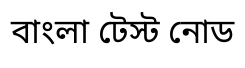

In [ ]:
from IPython.display import display
display(_label_image("বাংলা টেস্ট নোড"))

##7.Final Orchestration

[RETRY] Gemini overloaded/rate-limited -- attempt 1/4, waiting 1.0s...
[RETRY] Gemini overloaded/rate-limited -- attempt 2/4, waiting 2.6s...
Verification Status: YES
[INFO] Existing news (Matched ID: ART_218ba8a4 -> KG node: ART_218ba8a4)


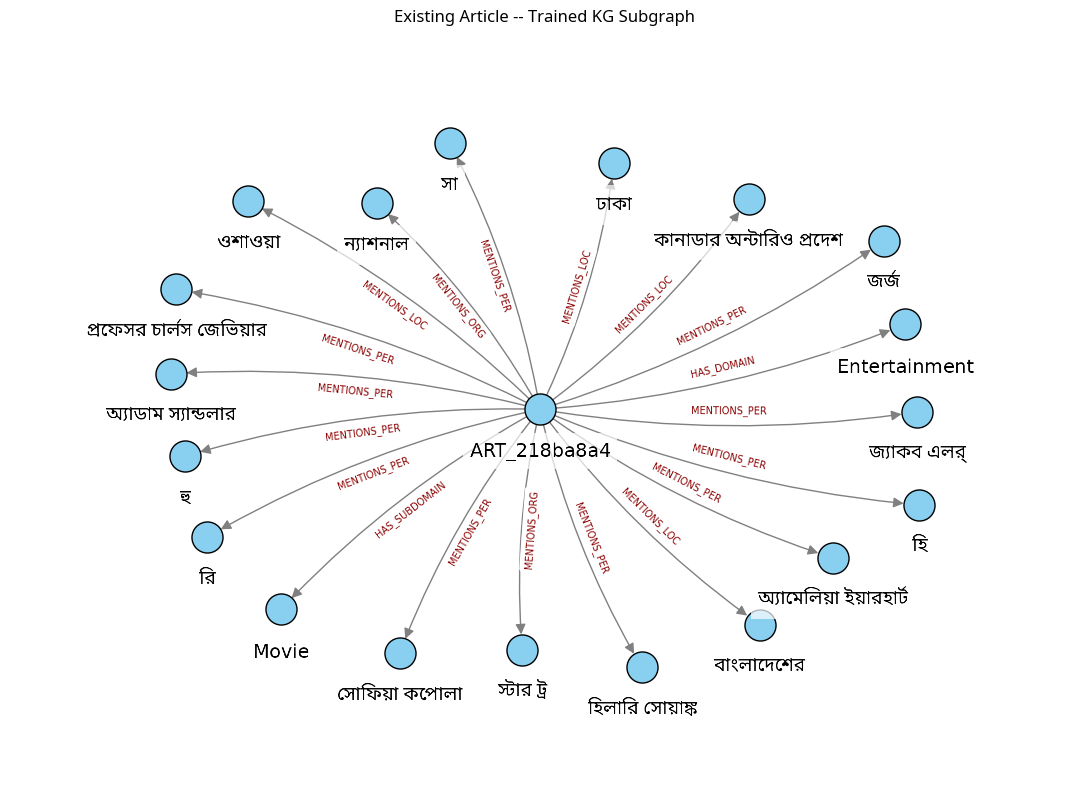

In [ ]:
if 'incoming_ques' in locals() and 'results' in locals():
    top_match_id = results['ids'][0][0] if results['ids'] else None
    top_match_text = results['documents'][0][0] if results['documents'] else ""

    # 1. Verify with Try-Except Fallback
    try:
        verif = verify_duplicate_event(incoming_ques, top_match_text)
        if 'error' in verif:
            print(f"[WARN] Gemini API Failed (Quota/Network). Treating as a NEW article for safety. Error: {verif['error']}")
            verif = {'same_news': 'NO'}
    except Exception as e:
        print(f"[WARN] Verification process encountered an exception: {e}. Treating as a NEW article.")
        verif = {'same_news': 'NO'}

    print(f"Verification Status: {verif.get('same_news')}")

    # 2. Route
    sub_g = handle_new_article(incoming_ques, verif, matched_article_id=top_match_id)

    # 3. Visualize
    if sub_g.number_of_nodes() > 0:
        title = ("Existing Article -- Trained KG Subgraph"
                  if verif.get('same_news') == 'YES'
                  else "New Article -- Live-Extracted Subgraph")
        visualize_subgraph(sub_g, title=title)
    else:
        print(f"[KG] No nodes to show for match ID: {top_match_id}")
else:
    print("Error: Search results or query not found. Age retrieval cell run koro.")

#Removing Ingested Nodes

In [ ]:
# import networkx as nx

# # গ্রাফের বর্তমান অবস্থা বিশ্লেষণ
# total_nodes = G.number_of_nodes()
# total_edges = G.number_of_edges()

# # নতুন ইনজেস্ট করা আর্টিক্যালগুলোর সংখ্যা দেখা (যেগুলো UUID দিয়ে শুরু হয়েছে)
# new_ingested_articles = [n for n in G.nodes() if str(n).startswith('ART_') and len(str(n)) > 10]
# original_articles = [n for n in G.nodes() if str(n).startswith('ART_') and len(str(n)) <= 10]

# print(f"--- Knowledge Graph Statistics ---")
# print(f"মোট নোড সংখ্যা: {total_nodes}")
# print(f"মোট রিলেশন (Edges) সংখ্যা: {total_edges}")
# print(f"পুরানো আর্টিক্যাল নোড: {len(original_articles)}")
# print(f"নতুন ডাইনামিকালি ইনজেস্ট করা নোড: {len(new_ingested_articles)}")

# if new_ingested_articles:
#     print(f"\nসর্বশেষ ইনজেস্ট করা নোড আইডি: {new_ingested_articles[-1]}")

In [ ]:
# import pickle
# import os

# # ১. ডাইনামিক নোডগুলো চিহ্নিত করা (length > 10)
# new_ingested_nodes = [n for n in G.nodes() if str(n).startswith('ART_') and len(str(n)) > 10]

# # ২. সর্বশেষ ৬টি নোড সিলেক্ট করা (যদি থাকে)
# nodes_to_remove = new_ingested_nodes[-6:]

# print(f"মুছে ফেলার জন্য নির্ধারিত নোডসমূহ: {nodes_to_remove}")

# # ৩. গ্রাফ থেকে নোডগুলো মুছে ফেলা
# for node in nodes_to_remove:
#     if G.has_node(node):
#         G.remove_node(node)
#         print(f"Node {node} removed.")

# # ৪. পরিবর্তিত গ্রাফটি ডিস্কে সেভ করা
# with open(KG_GRAPH_PATH, 'wb') as f:
#     pickle.dump(G, f)

# print(f"\nগ্রাফ আপডেট করা হয়েছে। বর্তমান নোড সংখ্যা: {G.number_of_nodes()}")

# # ৫. ইনজেশন কাউন্টার রিসেট করা (ঐচ্ছিক, ট্র্যাকিং ঠিক রাখার জন্য)
# if os.path.exists(COUNTER_PATH):
#     with open(COUNTER_PATH, 'w') as f:
#         import json
#         json.dump({"count": 0}, f)
#     print("Ingestion counter reset to 0.")

### Analyze Similarity Score Distribution

To determine an optimal similarity threshold, it's helpful to visualize the distribution of similarity scores across your dataset. This section will:

1. Select a few random documents from your DataFrame (`df`) to act as sample 'queries'.
2. Calculate the cosine similarity of each sample 'query' against all other documents in the dataset.
3. Plot a histogram and Kernel Density Estimate (KDE) of these similarity scores to show their distribution.

<a name="eval"></a>
### 8. Evaluation & Diagnostics

Calculating similarities for 50 sample queries...
Total similarity scores collected: 538050


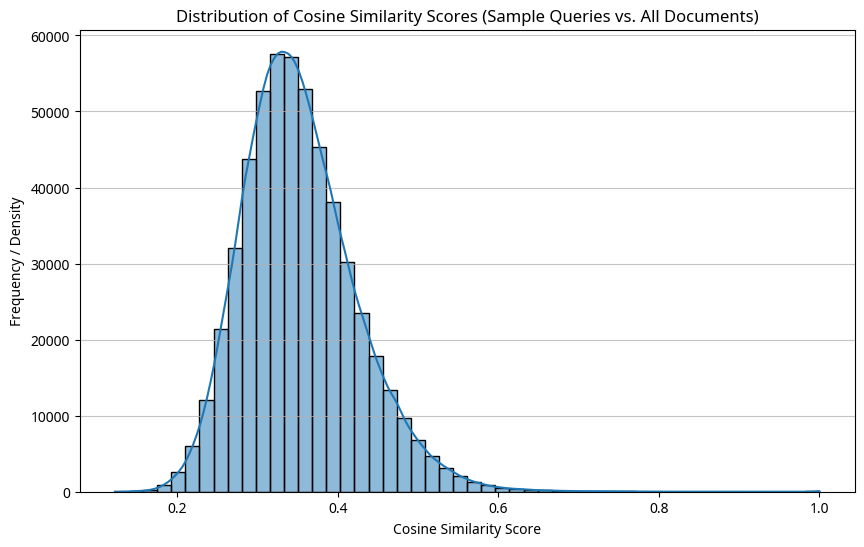


Based on this distribution, you can observe where most of your relevant and irrelevant scores fall to help decide on a threshold. For example, if you see a clear drop-off or gap, that might be a good candidate for your threshold.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Assuming 'df' and 'vectors' (or 'document_embeddings') are already defined and loaded
# from previous cells.
# 'document_embeddings' was defined in cell 'f69379ab'

# If document_embeddings is not yet defined, create it from vectors
if 'document_embeddings' not in locals() or document_embeddings is None:
    document_embeddings = np.array(vectors)

# Number of random documents to use as sample queries
num_sample_queries = 50 # Let's pick 50 random documents as queries for a good sample

# Get random indices for sample queries
random_indices = np.random.choice(len(df), num_sample_queries, replace=False)

all_similarities = []

print(f"Calculating similarities for {num_sample_queries} sample queries...")

for idx in random_indices:
    # Get the embedding for the current sample document (acting as a query)
    sample_query_embedding = document_embeddings[idx].reshape(1, -1)

    # Calculate similarities against all documents in the dataset
    # Exclude self-similarity if desired, or keep it as it's typically 1.0
    similarities = cosine_similarity(sample_query_embedding, document_embeddings)[0]

    # Add all similarities to the list, potentially excluding the self-similarity
    # For distribution, including it is fine, but for thresholding, we might want to see how queries relate to *other* documents.
    # Let's include all for a general distribution view.
    all_similarities.extend(similarities.tolist())

print(f"Total similarity scores collected: {len(all_similarities)}")

# Plot the distribution
fig = plt.figure(figsize=(10, 6))
sns.histplot(all_similarities, bins=50, kde=True)
plt.title('Distribution of Cosine Similarity Scores (Sample Queries vs. All Documents)')
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Frequency / Density')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\nBased on this distribution, you can observe where most of your relevant and irrelevant scores fall to help decide on a threshold. For example, if you see a clear drop-off or gap, that might be a good candidate for your threshold.")

### Searching at the Segment Level
To show multiple matches from the same file, we will now embed every individual segment separately rather than grouping them by filename.

In [ ]:
import numpy as np
import pandas as pd

# 1. Create the segment DataFrame from existing data
all_segments = []
for idx, row in df.head(len(vectors)).iterrows():
    all_segments.append({
        'original_index': idx,
        'Language': row['Language'],
        'text': row['Text'],
        'domain': row['Domain'],     # Added 'Domain' column
        'sub-domain': row['Sub-Domain'] # Added 'Sub-Domain' column
    })

segment_df = pd.DataFrame(all_segments)

# 2. Re-use existing vectors instead of re-embedding everything
# This avoids the 'ResponseError' caused by sending too much data at once
if 'vectors' in locals() and len(vectors) == len(segment_df):
    print("Re-using existing pre-computed vectors...")
    # Convert list of vectors to a numpy array for similarity calculations
    # Filtering out any potential None values from failed rows
    valid_vectors = [v if v is not None else [0]*1024 for v in vectors]
    seg_vectors = np.array(valid_vectors)
else:
    print("Existing vectors not found or size mismatch. Embedding in batches...")
    # Fallback: Batch processing to prevent connection errors
    batch_size = 32
    all_embs = []
    for i in range(0, len(segment_df), batch_size):
        batch_text = segment_df['text'].iloc[i:i+batch_size].tolist()
        res = ollama.embed(model='bge-m3', input=batch_text)
        all_embs.extend(res['embeddings'])
    seg_vectors = np.array(all_embs)

print(f"Total individual segments ready for search: {len(seg_vectors)}")

Re-using existing pre-computed vectors...
Total individual segments ready for search: 10761


Now we can perform a search that returns specific parts of a file, even multiple times from the same source.

In [ ]:
# Reshape query for similarity calculation
query_vec = np.array(query_embedding).reshape(1, -1)

# Calculate similarities
# We use seg_vectors which was generated in the previous cell
seg_similarities = cosine_similarity(query_vec, seg_vectors)[0]

# Add scores to our segment dataframe
segment_df['similarity_score'] = seg_similarities

# Sort and show top 10 results
# We display 'Language' and 'text' since 'filename' is not present in the data
top_segments = segment_df.sort_values(by='similarity_score', ascending=False).head(10)

print(f"Query: {incoming_ques[:100]}...")
display(top_segments[['Language', 'text','domain','sub-domain','similarity_score']])

Query: 
The place looked familiar. A massive white mansion stood within, fronted by rows of columns and sur...


,Language,text,domain,sub-domain,similarity_score
3567,bn,‘ক্রসওভার’—এই একটি শব্দ শুনলেই প্রিয়াঙ্কা চোপড়...,বিনোদন,সিনেমা,0.553742
2056,bn,সে–ই কবে এসেছিল ‘বেসিক ইন্সটিংক্ট’! সেই সাফল্য...,বিনোদন,সিনেমা,0.553453
10007,bn,সুপারম্যান তাহলে সত্যিই আছেন! কথাটা সামাজিক যো...,খেলাধুলা,ক্রিকেট,0.545342
1563,bn,"একসময় হলিউড মানেই ছিল শুধু অ্যাকশন, রোমান্টিক ...",বিনোদন,সিনেমা,0.536855
5353,bn,"রুদ্ধশ্বাস মুহূর্ত, দুর্দান্ত অ্যাকশন, টান টান...",বিনোদন,সিনেমা,0.533349
3304,bn,এইচবিওর সিরিজ ‘ইউফোরিয়া’ দিয়ে খ্যাতি পাওয়া ২৮ ...,বিনোদন,সিনেমা,0.532289
9891,bn,এইচবিওর সিরিজ ‘ইউফোরিয়া’ দিয়ে খ্যাতি পাওয়া ২৮ ...,বিনোদন,সিনেমা,0.528318
676,bn,"আর মাত্র ৮ দিন, ১৫ মার্চ যুক্তরাষ্ট্রের লস অ্য...",বিনোদন,সিনেমা,0.528173
7605,bn,২০২৫ সাল বিশ্ব বিনোদনজগতের জন্য ছিল এক রূপান্ত...,বিনোদন,সিনেমা,0.527077
6742,bn,দ্য হাউসমেইডধরন: সিনেমাস্ট্রিমিং: অ্যামাজন প্র...,বিনোদন,সিনেমা,0.524261


#

In [ ]:
def get_summary_context(incoming_ques, fallback_top_k=5):
    """LAST_NEW_ARTICLE_RETRIEVAL_DF ekhono current incoming_ques-er kina check kore,
    na hole stale bole dhore fallback kore -- Llama/Qwen/mT5 shob jaygay eki logic."""
    if (
        'LAST_NEW_ARTICLE_RETRIEVAL_DF' in globals()
        and not LAST_NEW_ARTICLE_RETRIEVAL_DF.empty
        and 'LAST_NEW_ARTICLE_TEXT' in globals()
        and LAST_NEW_ARTICLE_TEXT == incoming_ques
    ):
        return LAST_NEW_ARTICLE_RETRIEVAL_DF, 1

    if 'LAST_NEW_ARTICLE_RETRIEVAL_DF' in globals() and not LAST_NEW_ARTICLE_RETRIEVAL_DF.empty:
        print("[WARN] LAST_NEW_ARTICLE_RETRIEVAL_DF stale -- eta age-r query-r data. "
              "Cell 84 (Final Orchestration) notun incoming_ques diye abar run koro.")

    if 'top_segments' in globals() and not top_segments.empty:
        return top_segments, fallback_top_k

    return pd.DataFrame(), 1

#Llama 3.1:8b Summarizing Search Results with

In [ ]:
import ollama
import re

def summarize_with_llama31(query, results_df, model='llama3.1:8b', top_k=5):

    top_k_df = results_df.head(top_k)                              # FIX: top_k param, blind 5 na
    text_col = 'Text' if 'Text' in top_k_df.columns else 'text'     # FIX: column-casing fallback

    # 1. Dominant language detect
    if 'Language' in top_k_df.columns:
        dominant_lang = top_k_df['Language'].mode()[0]
    else:
        sample_text = " ".join(top_k_df[text_col].astype(str).tolist())
        bn_chars = len(re.findall(r'[\u0980-\u09FF]', sample_text))
        en_chars  = len(re.findall(r'[a-zA-Z]', sample_text))
        dominant_lang = 'bn' if bn_chars > en_chars else 'en'

    lang_name = "Bengali" if dominant_lang == 'bn' else "English"
    print(f"Target Language for Summary: {lang_name}")

    # 2. Context তৈরি
    context_chunks = top_k_df[text_col].astype(str).tolist()
    context = "\n\n---\n\n".join([
        f"Article {i+1}:\n{text[:1200]}"
        for i, text in enumerate(context_chunks)
    ])

    # 3. Language-specific prompt
    if dominant_lang == 'bn':
        prompt = f"""তুমি একজন দক্ষ বাংলা সংবাদ সম্পাদক।
নিচের সংবাদ নিবন্ধগুলো পড়ো এবং ব্যবহারকারীর প্রশ্নের ওপর ভিত্তি করে একটি চমৎকার সারসংক্ষেপ লেখো।

ব্যবহারকারীর প্রশ্ন: "{query}"

সংবাদ নিবন্ধসমূহ:
{context}

নির্দেশনাবলী:
- সর্বোচ্চ ৫টি বাক্য লিখুন—তবে কেবল ততটুকুই লিখুন যা তথ্যের ভিত্তিতে সমর্থিত। অপ্রয়োজনীয় কথা বা নিবন্ধে নেই এমন কোনো তথ্য যোগ করবেন না।
- ব্যবহারকারীর প্রশ্নের সঠিক উত্তর দেওয়ার চেষ্টা করবে।
- শুধু নিবন্ধে যা আছে তাই লিখবে, নিজে থেকে কিছু বানিয়ে লিখবে না।
- তথ্য, নাম, সংখ্যা এবং তারিখ যেন সঠিক থাকে।

বাংলায় সারসংক্ষেপ:"""
    else:
        prompt = f"""You are a professional news editor.
Read the following news articles and write an excellent summary based on the user's query.

User's Query: "{query}"

News Articles:
{context}

Rules:
- Write up to 5 sentences — only as many as the facts support. Do not pad or add information not in the articles.
- Focus on answering the user's query.
- Only include information from the articles — do not add anything new.
- Keep names, numbers, and dates accurate.

Summary in English:"""

    # 4. LLaMA call — settings tuned: low temp=faithful, repeat_penalty=1.15 (Bengali repeat-loop prone), stop tokens block context echo
    response = ollama.generate(
        model=model,
        prompt=prompt,
        options={
          'num_ctx': 8192,
          'temperature': 0.2,
          'top_p': 0.85,
          'top_k': 40,
          'repeat_penalty': 1.15,
          'num_predict': 700,
          'seed': 42,
          'stop': ['\n\n---', 'Article']
          }
    )
    return response['response']



# Run
context_df, tk = get_summary_context(incoming_ques)
if not context_df.empty:
    print("Generating Llama-3.1:8b summary...")
    summary_llama31 = summarize_with_llama31(incoming_ques, context_df, top_k=tk)
else:
    summary_llama31 = None
    print("Please run search/ingestion cell (84) first.")

if summary_llama31:
    print("\n=== Llama 3.1:8b Summary ===\n")
    print(summary_llama31)

Generating Llama-3.1:8b summary...
Target Language for Summary: Bengali

=== Llama 3.1:8b Summary ===

ওশাওয়া, অন্টারিয়োর এই পার্কউড বাড়িতে ২০০০ সালে 'X-Men' চলচ্চিত্রের অনেক গুরুত্বপূর্ণ দৃশ্য ধারণ হয়।


#Gemini 3.6 Flash API

In [ ]:
# import json
# import re
# import time
# import random
# from google.genai import types


# def summarize_with_gemini(
#     results_df,               # FIX: raw text na, DataFrame -- ekhon exact article summarize hobe
#     query=None,
#     top_k=1,                  # FIX: pipeline-e already exact single article (matched/new) thake
#     num_sentences=4,
#     force_lang=None,
#     model="gemini-3.6-flash",
#     max_retries=4,
# ):
#     """
#     Summarize Bengali / English / mixed-language news text with Gemini.
#     results_df: DataFrame with 'Text'/'text' column (from get_article_by_id / retrieval).
#     Returns dict: {"language": "bn"|"en"|"mixed", "summary": "...", "key_points": [...]}
#     """
#     if client is None:
#         return {"error": "Client not initialized. Check API Key."}

#     if results_df is None or results_df.empty:
#         return {"error": "No article text provided -- results_df empty."}

#     top_k_df = results_df.head(top_k)
#     text_col = 'Text' if 'Text' in top_k_df.columns else 'text'
#     text = "\n\n".join(top_k_df[text_col].astype(str).tolist())

#     if force_lang not in (None, 'bn', 'en'):
#         force_lang = None   # FIX: invalid value hole age English-e fixed hoye jeto, ekhon auto-detect fallback

#     lang_instruction = (
#         f"Write the summary in {'Bengali' if force_lang == 'bn' else 'English'}."
#         if force_lang else
#         "Detect the dominant language of the input (Bengali or English). "
#         "Write the summary in that SAME dominant language. "
#         "If the input is genuinely mixed with no dominant language, summarize in Bengali."
#     )

#     query_line = (
#         f'\nUser query for context (do NOT summarize this line, only the article below): "{query}"\n'
#         if query else ""
#     )

#     prompt = f"""
# You are a professional multilingual news summarizer for Bengali and English news.

# The input text may be:
# - Pure Bengali (বাংলা)
# - Pure English
# - Code-mixed Bengali-English (common in Bangladeshi news/social text)

# {lang_instruction}
# {query_line}
# RULES:
# - Do NOT translate the content into a different language than instructed above.
# - Do NOT invent facts, numbers, names, or dates not present in the input.
# - Preserve proper nouns (names, organizations, places) exactly as written in the input.
# - Be factual and neutral -- no opinions, no added commentary.
# - Summary should be exactly {num_sentences} sentences, capturing WHO, WHAT, WHERE, WHEN, WHY if available.
# - Also extract 3-5 short key points (bullet-style facts), in the same language as the summary.

# ========================
# INPUT TEXT
# ========================
# {text}

# ========================
# OUTPUT FORMAT
# ========================
# Return ONLY valid JSON, no markdown, no explanation:
# {{
#   "language": "bn" | "en" | "mixed",
#   "summary": "...",
#   "key_points": ["...", "...", "..."]
# }}
# """

#     for attempt in range(max_retries + 1):
#         raw = None
#         try:
#             response = client.models.generate_content(
#                 model=model,
#                 contents=prompt,
#                 config=types.GenerateContentConfig(
#                     response_mime_type="application/json",
#                     temperature=0.2,
#                 ),
#             )
#             raw = response.text.strip()
#             raw = re.sub(r"^```(json)?|```$", "", raw, flags=re.MULTILINE).strip()
#             return json.loads(raw)

#         except json.JSONDecodeError as e:
#             # FIX: age immediately return hoye jeto -- ekhon retry loop-e dhuke abar try kore
#             if attempt < max_retries:
#                 print(f"[RETRY] JSON parse failed -- attempt {attempt + 1}/{max_retries}, retrying...")
#                 time.sleep(1)
#                 continue
#             return {"error": f"JSON parse failed: {e}", "raw": raw}

#         except Exception as e:
#             err_str = str(e)
#             transient = any(tag in err_str for tag in ("503", "UNAVAILABLE", "429", "RESOURCE_EXHAUSTED"))
#             if transient and attempt < max_retries:
#                 wait = min(2 ** attempt, 30) + random.uniform(0, 1)
#                 print(f"[RETRY] Gemini overloaded -- attempt {attempt + 1}/{max_retries}, waiting {wait:.1f}s...")
#                 time.sleep(wait)
#                 continue
#             return {"error": err_str}

#     return {"error": "Max retries exhausted."}


# # Usage: exact matched/new article (1-row df) summarize -- query context hishebe pathano hocche, summarize hocche na
# if 'LAST_NEW_ARTICLE_RETRIEVAL_DF' in locals() and not LAST_NEW_ARTICLE_RETRIEVAL_DF.empty:
#     result = summarize_with_gemini(LAST_NEW_ARTICLE_RETRIEVAL_DF, query=incoming_ques, num_sentences=4)
# elif 'top_segments' in locals() and not top_segments.empty:
#     result = summarize_with_gemini(top_segments, query=incoming_ques, num_sentences=4)
# else:
#     result = {"error": "No article/context available -- run search/ingestion cell first."}

# if "error" in result:
#     print(f"Error occurred during summarization: {result['error']}")
#     if "raw" in result:
#         print(f"Raw response: {result['raw']}")
# else:
#     print(result["summary"])
#     print(result["key_points"])

# # যুক্তরাষ্ট্রের গ্রীষ্মকালীন বক্স অফিসে ১ মে থেকে ৭ সেপ্টেম্বর পর্যন্ত রেকর্ড ৪ দশমিক ৭৬ বিলিয়ন ডলার আয় হয়েছে, যা ২০১৩ সালের সর্বোচ্চ রেকর্ডকে পেছনে ফেলেছে। ইতিহাসে প্রথমবারের মতো এই মৌসুমে মে থেকে আগস্ট পর্যন্ত টানা চার মাসের প্রতিটিতেই আয় ১ বিলিয়ন ডলার অতিক্রম করেছে। ফ্র্যাঞ্চাইজিভিত্তিক সিনেমা যেমন সনির মার্ভেল ছবি ‘স্পাইডার–ম্যান: ব্র্যান্ড নিউ ডে’ এবং ক্রিস্টোফার নোলানের ‘দ্য অডিসি’ এই রেকর্ড আয়ে সবচেয়ে বড় ভূমিকা রেখেছে। তবে ডিজনির লাইভ–অ্যাকশন ‘মোয়ানা’ ও ডিসির ‘সুপারগার্ল’–এর মতো কিছু বড় বাজেটের ছবি প্রত্যাশিত ব্যবসা করতে পারেনি।
# # ['গ্রীষ্মকালীন বক্স অফিসে সর্বকালের রেকর্ড ৪.৭৬ বিলিয়ন ডলার আয় হয়েছে।', 'ইতিহাসে প্রথমবার মে থেকে আগস্ট পর্যন্ত টানা চার মাসের প্রতিটিতেই আয় ১ বিলিয়ন ডলার ছাড়িয়েছে।', '‘স্পাইডার–ম্যান: ব্র্যান্ড নিউ ডে’ বিশ্বব্যাপী প্রায় ২.৪ বিলিয়ন ডলার আয় করে শীর্ষে রয়েছে।', 'ক্রিস্টোফার নোলানের ‘দ্য অডিসি’ বিশ্বব্যাপী ১.৬২ বিলিয়ন ডলার আয় করেছে।']

#Llama 3.2 Summarizing Search Results with

This cell takes the top results from your search, constructs a prompt including all retrieved context, and uses the `llama3.2:3b` model to generate a concise summary.

In [ ]:
import ollama
import re

def summarize_with_llama32(query, results_df, model='llama3.2:3b', top_k=5):

    top_k_df = results_df.head(top_k)                              # FIX: top_k param, blind 5 na
    text_col = 'Text' if 'Text' in top_k_df.columns else 'text'     # FIX: column-casing fallback

    # 1. Dominant language detect
    if 'Language' in top_k_df.columns:
        dominant_lang = top_k_df['Language'].mode()[0]
    else:
        sample_text = " ".join(top_k_df[text_col].astype(str).tolist())
        bn_chars = len(re.findall(r'[\u0980-\u09FF]', sample_text))
        en_chars  = len(re.findall(r'[a-zA-Z]', sample_text))
        dominant_lang = 'bn' if bn_chars > en_chars else 'en'

    lang_name = "Bengali" if dominant_lang == 'bn' else "English"
    print(f"Target Language for Summary: {lang_name}")

    # 2. Context তৈরি
    context_chunks = top_k_df[text_col].astype(str).tolist()
    context = "\n\n---\n\n".join([
        f"Article {i+1}:\n{text[:1200]}"
        for i, text in enumerate(context_chunks)
    ])

    # 3. Language-specific prompt
    if dominant_lang == 'bn':
        prompt = f"""তুমি একজন দক্ষ বাংলা সংবাদ সম্পাদক।
নিচের সংবাদ নিবন্ধগুলো পড়ো এবং ব্যবহারকারীর প্রশ্নের ওপর ভিত্তি করে একটি চমৎকার সারসংক্ষেপ লেখো।

ব্যবহারকারীর প্রশ্ন: "{query}"

সংবাদ নিবন্ধসমূহ:
{context}

নির্দেশনাবলী:
- সর্বোচ্চ ৫টি বাক্য লিখুন—তবে কেবল ততটুকুই লিখুন যা তথ্যের ভিত্তিতে সমর্থিত। অপ্রয়োজনীয় কথা বা নিবন্ধে নেই এমন কোনো তথ্য যোগ করবেন না।
- ব্যবহারকারীর প্রশ্নের সঠিক উত্তর দেওয়ার চেষ্টা করবে।
- শুধু নিবন্ধে যা আছে তাই লিখবে, নিজে থেকে কিছু বানিয়ে লিখবে না।
- তথ্য, নাম, সংখ্যা এবং তারিখ যেন সঠিক থাকে।

বাংলায় সারসংক্ষেপ:"""
    else:
        prompt = f"""You are a professional news editor.
Read the following news articles and write an excellent summary based on the user's query.

User's Query: "{query}"

News Articles:
{context}

Rules:
- Write up to 5 sentences — only as many as the facts support. Do not pad or add information not in the articles.
- Focus on answering the user's query.
- Only include information from the articles — do not add anything new.
- Keep names, numbers, and dates accurate.

Summary in English:"""

    # 4. LLaMA call — settings tuned: low temp=faithful, repeat_penalty=1.15 (Bengali repeat-loop prone), stop tokens block context echo
    response = ollama.generate(
        model=model,
        prompt=prompt,
        options={
          'num_ctx': 8192,
          'temperature': 0.3,
          'top_p': 0.85,
          'top_k': 40,
          'repeat_penalty': 1.15,
          'num_predict': 700,
          'seed': 42,
          'stop': ['\n\n---', 'Article']
          }
    )
    return response['response']

# Run
context_df, tk = get_summary_context(incoming_ques)
if not context_df.empty:
    print("Generating Llama-3.2:3b summary...")
    summary_llama32 = summarize_with_llama32(incoming_ques, context_df, top_k=tk)
else:
    summary_llama32 = None
    print("Please run search/ingestion cell (84) first.")

if summary_llama32:
    print("\n=== Llama 3.2:3b Summary ===\n")
    print(summary_llama32)

Generating Llama-3.2:3b summary...
Target Language for Summary: Bengali

=== Llama 3.2:3b Summary ===

ওশাওয়া, অন্টারিওর একটি মাজা দেখাচ্ছে। আপনি যদি সেই বিখ্যাত "X-Mansion" নিঃসন্দেহে একটি মুভির অংশ, তা জানতে চান? প্রফেসর চার্লস জেভিয়ারের বিখ্যাত একাডেমির অন্যটি হলো ওশাওয়ার "Parkwood Estate"।


#Qwen 2.5:14b

In [ ]:
# Paste into Colab cell 104 (replaces old Qwen cell).
import ollama
import re
import subprocess

QWEN_MODEL = 'qwen2.5:14b'   # Ollama tag qwen2.5:14b IS the instruct model. No separate download.

# Pull only if model is missing from the Ollama store (Drive-backed OLLAMA_MODELS)
try:
    ollama.show(QWEN_MODEL)
    print(f"{QWEN_MODEL} found in Ollama store.")
except Exception:
    print(f"{QWEN_MODEL} not found, pulling...")
    subprocess.run(['ollama', 'pull', QWEN_MODEL], check=True)


def summarize_with_qwen14(query, results_df, model=QWEN_MODEL, top_k=5,
                          max_context_chars=3000, min_chars=60):

    top_k_df = results_df.head(top_k)
    text_col = 'Text' if 'Text' in top_k_df.columns else 'text'

    # 1. Dominant language detect
    if 'Language' in top_k_df.columns:
        dominant_lang = top_k_df['Language'].mode()[0]
    else:
        sample_text = " ".join(top_k_df[text_col].astype(str).tolist())
        bn_chars = len(re.findall(r'[\u0980-\u09FF]', sample_text))
        en_chars = len(re.findall(r'[a-zA-Z]', sample_text))
        dominant_lang = 'bn' if bn_chars > en_chars else 'en'

    lang_name = "Bengali" if dominant_lang == 'bn' else "English"
    print(f"Target Language for Summary: {lang_name}")

    # 2. Context: one fixed char budget split across articles.
    #    Qwen tokenizer spends many tokens per Bengali char, so keep it small.
    context_chunks = top_k_df[text_col].astype(str).tolist()
    per_article = max(800, max_context_chars // max(1, len(context_chunks)))
    context = "\n\n---\n\n".join(
        f"[News {i+1}]\n{text[:per_article]}" for i, text in enumerate(context_chunks)
    )

    # 3. New-article path: query IS the article. Do not paste it twice.
    q = str(query).strip()
    query_is_article = any(q[:200] == t.strip()[:200] for t in context_chunks)
    query_block = "" if query_is_article else f'User query: "{q[:500]}"\n\n'

    # 4. English instructions (cheap tokens, Qwen follows well), output language forced.
    system_msg = (
        "You are a professional news editor and factual summarizer. "
        f"Always write the final summary in {lang_name}."
    )
    user_msg = f"""{query_block}News:
{context}

Rules:
- Write up to 5 sentences — only as many as the facts support. Do not pad or add information not in the articles.
- Main event and most important facts first.
- Keep names, organizations, places, dates and numbers exact.
- Use only facts stated in the news. No guesses, no added causes, opinions or predictions.
- Do not repeat the same fact.
- No title, no introduction, no commentary. Output only the summary in {lang_name}."""

    messages = [
        {'role': 'system', 'content': system_msg},
        {'role': 'user', 'content': user_msg},
    ]

    def _call(temperature, seed):
        # FIX: temperature was 2 (Llama cells use 0.2/0.3). Stop list removed
        # (copied from Llama cell; 'Article' can cut the output). num_predict 350 -> 1200.
        r = ollama.chat(
            model=model,
            messages=messages,
            options={
                'num_ctx': 16384,
                'temperature': temperature,
                'top_p': 0.9,
                'top_k': 40,
                'repeat_penalty': 1.05,   # Qwen2.5 official default
                'num_predict': 1200,
                'seed': seed,
            },
        )
        print(f"[debug] prompt_tokens={r.get('prompt_eval_count')} "
              f"out_tokens={r.get('eval_count')} done_reason={r.get('done_reason')}")
        return r['message']['content'].strip()

    text = _call(temperature=0.2, seed=42)

    # Safety net: too-short output = failed generation. Retry once, slightly warmer.
    if len(text) < min_chars:
        print(f"[WARN] output only {len(text)} chars, retrying once...")
        text = _call(temperature=0.4, seed=7)
        if len(text) < min_chars:
            print("[WARN] still too short. Check [debug] line: prompt_tokens near 16384 = overflow "
                  "(lower max_context_chars); done_reason 'length' = raise num_predict.")

    return text


# Run — exact matched/new article priority, top_segments fallback
context_df, tk = get_summary_context(incoming_ques)
if not context_df.empty:
    print("Generating Qwen2.5-14 summary...")
    summary_qwen14 = summarize_with_qwen14(incoming_ques, context_df, top_k=tk)
else:
    summary_qwen14 = None
    print("Please run search/ingestion cell (84) first.")

if summary_qwen14:
    print("\n=== qwen14 Summary ===\n")
    print(summary_qwen14)

qwen2.5:14b found in Ollama store.
Generating Qwen2.5-14 summary...
Target Language for Summary: Bengali
[debug] prompt_tokens=3355 out_tokens=468 done_reason=stop

=== qwen14 Summary ===

পার্কউড এস্টেট, ওশাওয়া শহরের একটি ঐতিহ্যবাহী জায়গা, হলিউডের অনেক সফল চলচ্চিত্রের শুটিং লোকেশন হিসেবে ব্যবহৃত হয়েছে। ২০০০ সালের ফিল্ম 'এক্স-মেন' এই প্রাসাদটি ব্যবহার করেছিল প্রফেসর চার্লস জেভিয়ারের একাডেমির বাইরের দৃশ্য তৈরি করতে। পার্কউড ন্যাশনাল হিস্টোরিক সাইটের কিউরেটর সামান্থা জর্জ বলেছেন এখন পূর্ণদৈর্ঘ্য চলচ্চিত্রের বদলে টেলিভিশন ও স্ট্রিমিং প্ল্যাটফর্মের সিরিজ এখানে শুটিং হয়। 'স্টার ট্রেক' এবং 'বিলি ম্যাডিসন' এই প্রাসাদটি ব্যবহার করেছে।


#using Mt5 Model.

<a name="summary"></a>
### 7. Summarization Engine

In [ ]:
import re
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

saved_model_path = '/content/drive/MyDrive/ollama_models/mt5-buet'

print("Loading model and tokenizer from Google Drive...")
mt5_tokenizer = AutoTokenizer.from_pretrained(saved_model_path)
mt5_model = AutoModelForSeq2SeqLM.from_pretrained(saved_model_path)
print("Loaded successfully!")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mt5_model = mt5_model.to(device)
mt5_model.eval()
print(f"mT5 loaded on: {device}")

WHITESPACE_HANDLER = lambda text: re.sub(
    r'\s+', ' ', re.sub(r'\n+', ' ', str(text).strip())
)

def summarize_with_mt5(query, results_df, top_k=3, max_input=512, max_new=150, reserve_tokens=8):
    """
    max_input=512   -> XLSum fine-tune length, mismatch dile quality drop
    FIX (truncation): age char_per_token heuristic (bn=2,en=4) diye per-article
        char budget banano hoto -- approximate, kono kono jaygay mid-word/mid-sentence
        cut hoye jeto. Ekhon prottek article tokenizer diye actual token count e
        truncate kora hocche -- accurate, script-nirbhor na.
    reserve_tokens  -> special tokens (</s> etc) er jonno safety margin
    top_k=3         -> ekta na, multi-article context e dhukbe
    """
    top_k_df = results_df.head(top_k)
    text_col = 'Text' if 'Text' in top_k_df.columns else 'text'

    if 'Language' in top_k_df.columns:
        dominant_lang = top_k_df['Language'].mode()[0]
    else:
        sample = " ".join(top_k_df[text_col].astype(str).tolist())
        bn = len(re.findall(r'[\u0980-\u09FF]', sample))
        en = len(re.findall(r'[a-zA-Z]', sample))
        dominant_lang = 'bn' if bn > en else 'en'

    lang_name = "Bengali" if dominant_lang == 'bn' else "English"
    print(f"Target Language: {lang_name}")
    print(f"Articles found : {len(top_k_df)}")

    # ---- FIX: token-accurate per-article truncation (replaces char_per_token heuristic) ----
    num_articles = max(1, len(top_k_df))
    token_budget_per_article = max(20, (max_input - reserve_tokens) // num_articles)

    truncated_parts = []
    for _, row in top_k_df.iterrows():
        raw = WHITESPACE_HANDLER(str(row[text_col]))
        ids = mt5_tokenizer(
            raw, truncation=True, max_length=token_budget_per_article,
            add_special_tokens=False
        )['input_ids']
        truncated_parts.append(mt5_tokenizer.decode(ids, skip_special_tokens=True))

    combined = ' '.join(truncated_parts)

    inputs = mt5_tokenizer(
        [combined],
        return_tensors='pt',
        truncation=True,
        max_length=max_input,
        padding=True
    )
    input_ids      = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    actual_input_len = int(attention_mask.sum().item())

    min_new = max(15, min(60, actual_input_len // 4))

    with torch.no_grad():
        output_ids = mt5_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new,
            min_new_tokens=min_new,
            no_repeat_ngram_size=3,
            repetition_penalty=1.3,
            num_beams=4,
            early_stopping=True,
            length_penalty=1.0
        )[0]

    summary = mt5_tokenizer.decode(
        output_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )

    print(f"\n{'='*50}")
    print(f"Query   : {str(query)[:80]}...")
    print(f"{'='*50}")
    print(f"Summary :\n{summary}")
    print(f"{'='*50}")
    return summary


# ============================================================
# FIX (eval fairness): age smart_summary_pipeline(threshold=1.1) hack dive
# mT5-ke shomoy raw query-i summarize korano hoto (RAG context bypass) --
# Llama/Qwen/Gemini pura retrieved context pelo, mT5 pelo na -> apples-to-oranges.
# Ekhon threshold=0.5 (baki model-er shathe consistent) -- mT5 o real retrieved
# context e access pabe jokhon relevant match ache.
# ============================================================
def smart_summary_pipeline(query, search_results, threshold=0.6):
    if not search_results.empty and search_results.iloc[0]['similarity_score'] >= threshold:
        print(f"Relevant news found (Score: {search_results.iloc[0]['similarity_score']:.2f}). Summarizing retrieved context...")
        return summarize_with_mt5(query, search_results)
    else:
        print(f"No highly relevant news found (Score < {threshold}). Summarizing input query directly...")
        input_df = pd.DataFrame({'Text': [query], 'Language': ['bn']})
        return summarize_with_mt5(query, input_df)


# --- Execution ---
context_df, tk = get_summary_context(incoming_ques)
if not context_df.empty:
    print("Generating mT5 summary...")
    summary_mt5 = smart_summary_pipeline(incoming_ques, context_df.assign(
        similarity_score=context_df.get('similarity_score', 1.0)
    ), threshold=0.5)
else:
    summary_mt5 = None
    print("Please run search/ingestion cell (84) first.")

if summary_mt5:
    print("\n=== mT5 Summary ===\n")
    print(summary_mt5)

Loading model and tokenizer from Google Drive...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Loaded successfully!


[transformers] Both `max_new_tokens` (=150) and `max_length`(=84) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


mT5 loaded on: cuda
Generating mT5 summary...
Relevant news found (Score: 1.00). Summarizing retrieved context...
Target Language: Bengali
Articles found : 1

Query   : 
The place looked familiar. A massive white mansion stood within, fronted by row...
Summary :
এই বাড়িটা ছিল পর্দার সবচেয়ে আলোচিত একটি স্কুল। কিন্তু এখানে আশ্রয় নিতে হয়তো বিশেষ ক্ষমতার অধিকারী মিউট্যান্টরা। আর এই স্কুলের বাইরেও কোনো সিনেমা কিংবা সিরিজ দেখা যায়নি।

=== mT5 Summary ===

এই বাড়িটা ছিল পর্দার সবচেয়ে আলোচিত একটি স্কুল। কিন্তু এখানে আশ্রয় নিতে হয়তো বিশেষ ক্ষমতার অধিকারী মিউট্যান্টরা। আর এই স্কুলের বাইরেও কোনো সিনেমা কিংবা সিরিজ দেখা যায়নি।


#Metrices

### Hallucination Rate Analysis
হ্যালুসিনেশন রেট সাধারণত NLI (Natural Language Inference) মডেল ব্যবহার করে বের করা হয়, যেখানে দেখা হয় সামারির তথ্যগুলো মূল টেক্সট দ্বারা সমর্থিত কি না। উপরে প্রাপ্ত ROUGE-L এবং BERTScore-এর মান যত কম হবে, হ্যালুসিনেশনের সম্ভাবনা তত বেশি বলে ধরে নেওয়া যায়।

In [ ]:
# # ============================================================
# # PROPER RAG SUMMARIZATION EVALUATION
# # ============================================================
# #
# # IMPORTANT:
# # 1. ROUGE/BERTScore require HUMAN reference summaries.
# # 2. Query document is excluded from retrieval to avoid
# #    self-retrieval / data leakage.
# # 3. NLI is reported as a factual-support proxy, not as
# #    a perfect hallucination detector.
# # 4. Overall results show MEAN + STD.
# # ============================================================

# !pip install -q rouge_score bert_score

# import re
# import time
# import json
# import numpy as np
# import pandas as pd
# import torch

# from rouge_score import rouge_scorer
# from bert_score import BERTScorer
# from transformers import pipeline as hf_pipeline


# # ============================================================
# # 1. CONFIGURATION
# # ============================================================

# SAMPLES_PER_DOMAIN = 5
# RANDOM_STATE = 42

# TOP_K = 5
# SIMILARITY_THRESHOLD = 0.6

# # NLI threshold:
# # This is a heuristic threshold.
# # For a research paper, ideally calibrate it using
# # manually labelled validation examples.
# NLI_ENTAILMENT_THRESHOLD = 0.70
# NLI_CONTRADICTION_THRESHOLD = 0.70

# EVAL_EXPORT_PATH = "eval_queries.json"

# # ------------------------------------------------------------
# # HUMAN REFERENCE SUMMARY COLUMN
# # ------------------------------------------------------------
# #
# # If your main dataframe already contains a human-written
# # summary, put its column name here.
# #
# # Example:
# #   "Summary"
# #   "Reference_Summary"
# #
# # If no such column exists, ROUGE/BERTScore will be skipped.
# # ------------------------------------------------------------

# REFERENCE_COL = "Reference_Summary"


# # ============================================================
# # 2. CHECK DATASET
# # ============================================================

# assert len(df) == len(vectors), \
#     "ERROR: len(df) and len(vectors) must be identical."

# # domain_aware_search_pretrained assumes vector index == df index
# if not np.array_equal(df.index.to_numpy(), np.arange(len(df))):
#     raise ValueError(
#         "df index is not 0..N-1. Reset/rebuild the dataframe index "
#         "before using vector_idx-based exclusion."
#     )

# print(f"Dataset size : {len(df)}")
# print(f"Domains      : {df['Domain'].nunique()}")

# if REFERENCE_COL in df.columns:
#     valid_ref_count = (
#         df[REFERENCE_COL]
#         .fillna("")
#         .astype(str)
#         .str.strip()
#         .ne("")
#         .sum()
#     )

#     print(
#         f"Human reference summaries found: "
#         f"{valid_ref_count}/{len(df)}"
#     )
# else:
#     print(
#         "\nWARNING:"
#         f" '{REFERENCE_COL}' column was not found."
#     )
#     print(
#         "ROUGE and BERTScore will NOT be reported as standard "
#         "summarization metrics."
#     )


# # ============================================================
# # 3. MULTILINGUAL NLI MODEL
# # ============================================================

# print("\nLoading multilingual NLI model...")

# try:
#     nli_pipe = hf_pipeline(
#         "text-classification",
#         model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
#         device=0 if torch.cuda.is_available() else -1
#     )

# except Exception as e:
#     print(f"NLI GPU loading failed: {e}")
#     print("Falling back to CPU...")

#     nli_pipe = hf_pipeline(
#         "text-classification",
#         model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
#         device=-1
#     )

# print("NLI model loaded.")


# # ============================================================
# # 4. BERTSCORE
# # ============================================================
# #
# # Bengali + English mixed evaluation-এর জন্য একটি fixed
# # multilingual model use করা হচ্ছে যাতে different language
# # অনুযায়ী model বদলে না যায়.
# # ============================================================

# bert_scorer = None

# reference_available = (
#     REFERENCE_COL in df.columns
#     and
#     df[REFERENCE_COL]
#     .fillna("")
#     .astype(str)
#     .str.strip()
#     .ne("")
#     .any()
# )

# if reference_available:

#     print("\nLoading multilingual BERTScore model...")

#     bert_scorer = BERTScorer(
#         model_type="bert-base-multilingual-cased",
#         rescale_with_baseline=False,
#         device="cuda" if torch.cuda.is_available() else "cpu"
#     )

#     print("BERTScore model loaded.")

# else:

#     print(
#         "\nBERTScore model skipped because "
#         "human reference summaries are unavailable."
#     )


# # ============================================================
# # 5. SENTENCE SPLITTER
# # ============================================================

# def split_sentences(text):
#     """
#     Bengali + English sentence splitting.
#     """

#     parts = re.split(
#         r'[।.!?]+\s*',
#         str(text)
#     )

#     return [
#         p.strip()
#         for p in parts
#         if len(p.strip()) > 3
#     ]


# # ============================================================
# # 6. BUILD EVIDENCE CONTEXT
# # ============================================================

# def build_evidence_context(query_text, results_df,
#                            max_chars_per_doc=1200):

#     evidence = []

#     # Original query/source article
#     if query_text:
#         evidence.append(
#             f"Original Source:\n{str(query_text)[:2000]}"
#         )

#     # Retrieved documents
#     if results_df is not None and not results_df.empty:

#         text_col = (
#             "Text"
#             if "Text" in results_df.columns
#             else "text"
#         )

#         for i, txt in enumerate(
#             results_df[text_col].astype(str).tolist()
#         ):

#             evidence.append(
#                 f"Retrieved Article {i+1}:\n"
#                 f"{txt[:max_chars_per_doc]}"
#             )

#     return evidence


# # ============================================================
# # 7. NLI-BASED FACTUAL SUPPORT
# # ============================================================
# #
# # IMPORTANT:
# # This is NOT a perfect hallucination detector.
# #
# # We measure:
# #
# # Supported      = evidence entails summary sentence
# # Contradicted   = evidence contradicts summary sentence
# # Uncertain      = neither strong entailment nor contradiction
# #
# # Therefore, "NLI Unsupported Rate" is a proxy.
# # ============================================================

# def nli_factuality(summary_text,
#                    evidence_texts,
#                    entail_threshold=NLI_ENTAILMENT_THRESHOLD,
#                    contradiction_threshold=NLI_CONTRADICTION_THRESHOLD):

#     sentences = split_sentences(summary_text)

#     if not sentences:
#         return {
#             "NLI Support Rate": np.nan,
#             "NLI Contradiction Rate": np.nan,
#             "NLI Uncertain Rate": np.nan,
#             "NLI Unsupported Rate": np.nan
#         }

#     supported = 0
#     contradicted = 0
#     uncertain = 0

#     for sentence in sentences:

#         if not evidence_texts:
#             uncertain += 1
#             continue

#         pairs = [
#             {
#                 "text": evidence,
#                 "text_pair": sentence
#             }
#             for evidence in evidence_texts
#         ]

#         try:

#             outputs = nli_pipe(
#                 pairs,
#                 truncation=True,
#                 top_k=None,
#                 batch_size=8
#             )

#             # Make sure output is a list for each pair
#             if outputs and isinstance(outputs[0], dict):
#                 outputs = [outputs]

#             best_entailment = 0.0
#             best_contradiction = 0.0

#             for pair_output in outputs:

#                 for item in pair_output:

#                     label = str(
#                         item["label"]
#                     ).lower()

#                     score = float(
#                         item["score"]
#                     )

#                     if "entail" in label:
#                         best_entailment = max(
#                             best_entailment,
#                             score
#                         )

#                     elif "contradict" in label:
#                         best_contradiction = max(
#                             best_contradiction,
#                             score
#                         )

#             if best_entailment >= entail_threshold:

#                 supported += 1

#             elif best_contradiction >= contradiction_threshold:

#                 contradicted += 1

#             else:

#                 uncertain += 1

#         except Exception as e:

#             print(
#                 f"NLI error for sentence: "
#                 f"{sentence[:80]}... -> {e}"
#             )

#             uncertain += 1

#     total = len(sentences)

#     return {
#         "NLI Support Rate": supported / total,
#         "NLI Contradiction Rate": contradicted / total,
#         "NLI Uncertain Rate": uncertain / total,
#         "NLI Unsupported Rate": (
#             (contradicted + uncertain) / total
#         )
#     }


# # ============================================================
# # 8. FIXED RETRIEVAL FUNCTION
# # ============================================================
# #
# # MAIN FIX:
# # exclude_vector_idx prevents the query article from
# # retrieving itself.
# # ============================================================

# def domain_aware_search_eval(
#         query_text,
#         top_k=10,
#         threshold=0.6,
#         exclude_vector_idx=None):

#     # --------------------------------------------------------
#     # Domain prediction
#     # --------------------------------------------------------

#     domain_name = predict_domain(
#         query_text,
#         loaded_domain_model,
#         loaded_domain_tokenizer,
#         domain_label_encoder,
#         MAX_LENGTH_DOMAIN
#     )

#     domain_id = ID_MAP.get(
#         domain_name,
#         -1
#     )

#     # --------------------------------------------------------
#     # Language detection
#     # --------------------------------------------------------

#     bn = len(
#         re.findall(
#             r'[\u0980-\u09FF]',
#             query_text
#         )
#     )

#     en = len(
#         re.findall(
#             r'[a-zA-Z]',
#             query_text
#         )
#     )

#     lang = "bn" if bn > en else "en"

#     # --------------------------------------------------------
#     # Master dataframe
#     # --------------------------------------------------------

#     df_results = df.head(
#         len(vectors)
#     ).copy()

#     df_results["vector_idx"] = range(
#         len(df_results)
#     )

#     # --------------------------------------------------------
#     # Domain + Language filter
#     # --------------------------------------------------------

#     filtered = df_results[
#         (df_results["Language"] == lang) &
#         (df_results["Domain_ID"] == domain_id)
#     ].copy()

#     # --------------------------------------------------------
#     # FALLBACK
#     # --------------------------------------------------------

#     if filtered.empty:

#         filtered = df_results[
#             df_results["Language"] == lang
#         ].copy()

#     # --------------------------------------------------------
#     # REMOVE SELF DOCUMENT
#     # --------------------------------------------------------

#     if exclude_vector_idx is not None:

#         filtered = filtered[
#             filtered["vector_idx"]
#             != exclude_vector_idx
#         ].copy()

#     if filtered.empty:

#         return pd.DataFrame()

#     # --------------------------------------------------------
#     # Semantic similarity
#     # --------------------------------------------------------

#     pool_indices = (
#         filtered["vector_idx"]
#         .astype(int)
#         .tolist()
#     )

#     f_vectors = np.array(
#         [vectors[i] for i in pool_indices]
#     )

#     query_vec = np.array(
#         ollama.embed(
#             model="bge-m3",
#             input=[query_text]
#         )["embeddings"][0]
#     ).reshape(1, -1)

#     sims = cosine_similarity(
#         query_vec,
#         f_vectors
#     )[0]

#     filtered["similarity_score"] = sims

#     # --------------------------------------------------------
#     # Sub-domain prediction
#     # --------------------------------------------------------

#     sub_domain_input = (
#         f"{domain_name} {query_text}"
#     )

#     predicted_sub_domain = predict_sub_domain(
#         sub_domain_input,
#         loaded_sub_domain_model,
#         loaded_sub_domain_tokenizer,
#         sub_domain_label_encoder,
#         MAX_LENGTH_SUB_DOMAIN
#     )

#     sub_filtered = filtered[
#         filtered["Sub-Domain"]
#         == predicted_sub_domain
#     ].copy()

#     # --------------------------------------------------------
#     # FALLBACK if sub-domain has no result
#     # --------------------------------------------------------

#     if sub_filtered.empty:

#         sub_filtered = filtered.copy()

#     # --------------------------------------------------------
#     # Threshold + ranking
#     # --------------------------------------------------------

#     result = (
#         sub_filtered[
#             sub_filtered["similarity_score"]
#             >= threshold
#         ]
#         .sort_values(
#             "similarity_score",
#             ascending=False
#         )
#         .head(top_k)
#     )

#     return result


# # ============================================================
# # 9. MODEL GENERATION WRAPPERS
# # ============================================================

# def llama_generate_fn(
#         query,
#         results_df,
#         model="llama3.1:8b"):

#     df_copy = results_df.copy()

#     if (
#         "text" not in df_copy.columns
#         and
#         "Text" in df_copy.columns
#     ):
#         df_copy["text"] = df_copy["Text"]

#     return summarize_results(
#         query,
#         df_copy,
#         model=model
#     )


# def qwen_generate_fn(
#         query,
#         results_df,
#         model="qwen2.5:14b"):

#     return summarize_with_qwen14(
#         query,
#         results_df,
#         model=model
#     )


# def gemini_generate_fn(
#         query,
#         results_df,
#         model="gemini-3.6-flash"):

#     result = summarize_with_gemini(
#         results_df,
#         query=query,
#         num_sentences=4,
#         model=model
#     )

#     if "error" in result:
#         raise RuntimeError(
#             result["error"]
#         )

#     return result["summary"]


# # ============================================================
# # 10. SINGLE SAMPLE EVALUATION
# # ============================================================

# def evaluate_one(
#         model_name,
#         generate_fn,
#         query,
#         reference_summary,
#         top_results,
#         domain):

#     start_time = time.time()

#     # --------------------------------------------------------
#     # Generate summary
#     # --------------------------------------------------------

#     try:

#         candidate = generate_fn(
#             query,
#             top_results
#         )

#         if (
#             candidate is None
#             or
#             len(str(candidate).strip()) < 5
#         ):
#             raise ValueError(
#                 "Empty/invalid model output."
#             )

#         candidate = str(candidate).strip()

#     except Exception as e:

#         return {
#             "Model": model_name,
#             "Domain": domain,
#             "Status": "Failed",
#             "Error": str(e)
#         }

#     latency = (
#         time.time() - start_time
#     )

#     result = {
#         "Model": model_name,
#         "Domain": domain,
#         "Status": "Success",
#         "Latency (s)": latency,
#         "Output Words": len(
#             candidate.split()
#         )
#     }

#     # ========================================================
#     # A. ROUGE + BERTScore
#     # ========================================================

#     if (
#         reference_summary is not None
#         and
#         str(reference_summary).strip()
#     ):

#         reference_summary = str(
#             reference_summary
#         ).strip()

#         scorer = rouge_scorer.RougeScorer(
#             [
#                 "rouge1",
#                 "rouge2",
#                 "rougeL"
#             ],
#             use_stemmer=False
#         )

#         rouge_result = scorer.score(
#             reference_summary,
#             candidate
#         )

#         result["ROUGE-1"] = (
#             rouge_result["rouge1"].fmeasure
#         )

#         result["ROUGE-2"] = (
#             rouge_result["rouge2"].fmeasure
#         )

#         result["ROUGE-L"] = (
#             rouge_result["rougeL"].fmeasure
#         )

#         # BERTScore
#         P, R, F1 = bert_scorer.score(
#             [candidate],
#             [reference_summary],
#             batch_size=1
#         )

#         result["BERTScore-P"] = P.item()
#         result["BERTScore-R"] = R.item()
#         result["BERTScore-F1"] = F1.item()

#     else:

#         result["ROUGE-1"] = np.nan
#         result["ROUGE-2"] = np.nan
#         result["ROUGE-L"] = np.nan

#         result["BERTScore-P"] = np.nan
#         result["BERTScore-R"] = np.nan
#         result["BERTScore-F1"] = np.nan

#     # ========================================================
#     # B. FACTUAL CONSISTENCY / NLI
#     # ========================================================

#     evidence_texts = build_evidence_context(
#         query_text=query,
#         results_df=top_results,
#         max_chars_per_doc=1200
#     )

#     nli_result = nli_factuality(
#         candidate,
#         evidence_texts
#     )

#     result.update(
#         nli_result
#     )

#     return result


# # ============================================================
# # 11. BUILD FIXED TEST SET
# # ============================================================

# test_set = []

# for domain_name in sorted(
#     df["Domain"].dropna().unique()
# ):

#     domain_indices = df.index[
#         df["Domain"] == domain_name
#     ].tolist()

#     if not domain_indices:
#         continue

#     rng = np.random.RandomState(
#         RANDOM_STATE
#     )

#     sampled_indices = rng.choice(
#         domain_indices,
#         size=min(
#             SAMPLES_PER_DOMAIN,
#             len(domain_indices)
#         ),
#         replace=False
#     )

#     for idx in sampled_indices:

#         row = df.loc[idx]

#         reference_summary = None

#         if REFERENCE_COL in df.columns:

#             value = row.get(
#                 REFERENCE_COL,
#                 ""
#             )

#             if pd.notna(value):

#                 value = str(value).strip()

#                 if value:
#                     reference_summary = value

#         test_set.append(
#             {
#                 "vector_idx": int(idx),
#                 "domain": domain_name,
#                 "text": str(row["Text"]),
#                 "reference_summary":
#                     reference_summary
#             }
#         )


# print(
#     f"\nTotal test samples: "
#     f"{len(test_set)}"
# )

# print(
#     f"Domains evaluated: "
#     f"{len(set(x['domain'] for x in test_set))}"
# )


# # ============================================================
# # 12. EXPORT TEST SET
# # ============================================================

# with open(
#     EVAL_EXPORT_PATH,
#     "w",
#     encoding="utf-8"
# ) as f:

#     json.dump(
#         test_set,
#         f,
#         ensure_ascii=False,
#         indent=2
#     )

# print(
#     f"Evaluation queries exported to: "
#     f"{EVAL_EXPORT_PATH}"
# )


# # ============================================================
# # 13. MODEL LIST
# # ============================================================

# model_configs = [

#     (
#         "mT5-XLSum",
#         lambda q, r:
#             smart_summary_pipeline(
#                 q,
#                 r,
#                 threshold=1.1   # FIX: always fallback -> source(q) summarize hoy,
#                                 # Llama/Qwen-er moto source dekhe, neighbor-nirbhor thake na
#             )
#     ),

#     (
#         "Llama-3.1-8B",
#         lambda q, r:
#             llama_generate_fn(
#                 q,
#                 r,
#                 model="llama3.1:8b"
#             )
#     ),

#     (
#         "Llama-3.2-3B",
#         lambda q, r:
#             llama_generate_fn(
#                 q,
#                 r,
#                 model="llama3.2:3b"
#             )
#     ),

#     (
#         "Qwen-2.5-14B",
#         lambda q, r:
#             qwen_generate_fn(
#                 q,
#                 r,
#                 model="qwen2.5:14b"
#             )
#     ),
#     (
#         "Gemini-3.6-Flash",
#         lambda q, r:
#             gemini_generate_fn(
#                 q,
#                 r
#             )
#     )
# ]


# # ============================================================
# # 14. MAIN EVALUATION
# # ============================================================

# all_results = []

# for i, item in enumerate(test_set):

#     query = item["text"]
#     domain = item["domain"]

#     exclude_idx = item[
#         "vector_idx"
#     ]

#     reference_summary = item[
#         "reference_summary"
#     ]

#     print(
#         f"\n{'=' * 70}"
#     )

#     print(
#         f"Evaluation "
#         f"{i+1}/{len(test_set)}"
#     )

#     print(
#         f"Domain: {domain}"
#     )

#     print(
#         f"Self document excluded: "
#         f"vector_idx={exclude_idx}"
#     )

#     print(
#         f"{'=' * 70}"
#     )

#     # --------------------------------------------------------
#     # Retrieval
#     # --------------------------------------------------------

#     try:

#         top_results_eval = (
#             domain_aware_search_eval(
#                 query_text=query,
#                 top_k=TOP_K,
#                 threshold=SIMILARITY_THRESHOLD,
#                 exclude_vector_idx=exclude_idx
#             )
#         )

#     except Exception as e:

#         print(
#             f"[Retrieval Error] {e}"
#         )

#         continue

#     if top_results_eval.empty:

#         print(
#             "[SKIP] No retrieval results."
#         )

#         continue

#     print(
#         f"Retrieved documents: "
#         f"{len(top_results_eval)}"
#     )

#     # --------------------------------------------------------
#     # Run every model on SAME retrieved context
#     # --------------------------------------------------------

#     for model_name, generate_fn in model_configs:

#         print(
#             f"\nRunning: {model_name}"
#         )

#         result = evaluate_one(
#             model_name=model_name,
#             generate_fn=generate_fn,
#             query=query,
#             reference_summary=reference_summary,
#             top_results=top_results_eval,
#             domain=domain
#         )

#         all_results.append(result)


# # ============================================================
# # 15. RESULTS DATAFRAME
# # ============================================================

# results_df = pd.DataFrame(
#     all_results
# )

# print(
#     "\n\n================ RAW RESULTS ================"
# )

# display(
#     results_df
# )


# # ============================================================
# # 16. SUCCESSFUL RESULTS ONLY
# # ============================================================

# success_df = results_df[
#     results_df["Status"] == "Success"
# ].copy()


# # ============================================================
# # 17. OVERALL RESULT: MEAN + STD
# # ============================================================

# metric_columns = [

#     "ROUGE-1",
#     "ROUGE-2",
#     "ROUGE-L",

#     "BERTScore-P",
#     "BERTScore-R",
#     "BERTScore-F1",

#     "NLI Support Rate",
#     "NLI Contradiction Rate",
#     "NLI Uncertain Rate",
#     "NLI Unsupported Rate",

#     "Latency (s)",
#     "Output Words"
# ]


# available_metrics = [
#     c
#     for c in metric_columns
#     if c in success_df.columns
# ]


# overall_metrics = (
#     success_df
#     .groupby("Model")[
#         available_metrics
#     ]
#     .agg(["mean", "std"])
#     .round(4)
# )


# print(
#     "\n\n================ OVERALL RESULT "
#     "(MEAN ± STD) ================"
# )

# display(
#     overall_metrics
# )


# # ============================================================
# # 18. PER-DOMAIN RESULT
# # ============================================================

# per_domain_metrics = (
#     success_df
#     .groupby(
#         ["Model", "Domain"]
#     )[available_metrics]
#     .mean()
#     .round(4)
# )

# print(
#     "\n\n================ PER-DOMAIN RESULT ================"
# )

# display(
#     per_domain_metrics
# )


# # ============================================================
# # 19. SAVE RESULTS
# # ============================================================

# RESULT_CSV = (
#     "proper_evaluation_results.csv"
# )

# results_df.to_csv(
#     RESULT_CSV,
#     index=False,
#     encoding="utf-8-sig"
# )

# print(
#     f"\nDetailed results saved to: "
#     f"{RESULT_CSV}"
# )

## without gemini

In [ ]:
# # ============================================================
# # FIXED EVALUATION CELL — matched multi-domain, multi-sample
# # + adds Llama-3.1-8B alongside Llama-3.2-3B (both were being
# #   collapsed into 3.1:8b due to unbound model param — fixed)
# # + adds Qwen-2.5-14B — 4 models total now
# # ============================================================

# !pip install -q rouge_score bert_score
# import time, re, json
# import numpy as np
# import pandas as pd
# import torch
# from rouge_score import rouge_scorer
# from bert_score import score as bert_score_fn
# from transformers import pipeline as hf_pipeline

# SAMPLES_PER_DOMAIN = 5
# RANDOM_STATE = 42
# EVAL_EXPORT_PATH = "eval_queries.json"

# def is_bengali(text):
#     return bool(re.search(r'[\u0980-\u09FF]', str(text)))

# print("Loading multilingual NLI model for hallucination check...")
# try:
#     nli_pipe = hf_pipeline(
#         "text-classification",
#         model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
#         device=0 if torch.cuda.is_available() else -1
#     )
# except Exception as e:
#     print(f"NLI Model loading failed: {e}. Falling back to CPU.")
#     nli_pipe = hf_pipeline(
#         "text-classification",
#         model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
#         device=-1
#     )

# def split_sentences(text):
#     parts = re.split(r'[।.!?]\s*', str(text))
#     return [p.strip() for p in parts if len(p.strip()) > 3]

# def hallucination_rate(source_text, summary_text, max_chars=2000):
#     sentences = split_sentences(summary_text)
#     if not sentences:
#         return 1.0
#     unsupported = 0
#     premise = str(source_text)[:max_chars]
#     for sent in sentences:
#         res_list = nli_pipe({"text": premise, "text_pair": sent}, truncation=True)
#         result = res_list[0] if isinstance(res_list, list) else res_list
#         if 'entail' not in result['label'].lower():
#             unsupported += 1
#     return unsupported / len(sentences)

# # ------------------------------------------------------------
# # Llama wrapper — model param thread kora, sathik function pick kora
# # ------------------------------------------------------------
# def llama_generate_fn(query, results_df, model='llama3.1:8b'):
#     df_copy = results_df.copy()
#     if 'text' not in df_copy.columns and 'Text' in df_copy.columns:
#         df_copy['text'] = df_copy['Text']
#     fn = summarize_with_llama31 if '3.1' in model else summarize_with_llama32
#     return fn(query, df_copy, model=model)

# # ------------------------------------------------------------
# # Qwen wrapper
# # ------------------------------------------------------------
# def qwen_generate_fn(query, results_df, model='qwen2.5:14b'):
#     return summarize_with_qwen14(query, results_df, model=model)

# # ------------------------------------------------------------
# # Prediction functions — as-is
# # ------------------------------------------------------------
# def predict_domain(text, model, tokenizer, label_encoder, max_length):
#     model.eval()
#     inputs = tokenizer(
#         text, add_special_tokens=True, max_length=max_length,
#         padding='max_length', return_token_type_ids=True,
#         truncation=True, return_tensors='pt'
#     )
#     ids = inputs['input_ids'].to(device)
#     mask = inputs['attention_mask'].to(device)
#     token_type_ids = inputs['token_type_ids'].to(device)
#     with torch.no_grad():
#         outputs = model(ids, attention_mask=mask, token_type_ids=token_type_ids)
#         logits = outputs.logits
#     probabilities = torch.softmax(logits, dim=1).cpu().numpy()
#     predicted_class_idx = np.argmax(probabilities, axis=1)[0]
#     return label_encoder[predicted_class_idx]

# def predict_sub_domain(text, model, tokenizer, label_encoder, max_length):
#     model.eval()
#     inputs = tokenizer(
#         text, add_special_tokens=True, max_length=max_length,
#         padding='max_length', return_token_type_ids=True,
#         truncation=True, return_tensors='pt'
#     )
#     ids = inputs['input_ids'].to(device)
#     mask = inputs['attention_mask'].to(device)
#     token_type_ids = inputs['token_type_ids'].to(device)
#     with torch.no_grad():
#         outputs = model(ids, attention_mask=mask, token_type_ids=token_type_ids)
#         logits = outputs.logits
#     probabilities = torch.softmax(logits, dim=1).cpu().numpy()
#     predicted_class_idx = np.argmax(probabilities, axis=1)[0]
#     return label_encoder[predicted_class_idx]

# print("Prediction functions 'predict_domain' and 'predict_sub_domain' defined.")

# def domain_aware_search_pretrained(query_text, top_k=10, threshold=0.6):
#     domain_name = predict_domain(
#         query_text, loaded_domain_model, loaded_domain_tokenizer,
#         domain_label_encoder, MAX_LENGTH_DOMAIN
#     )
#     domain_id = ID_MAP.get(domain_name, -1)
#     print(f"Domain detected  : {domain_name} (pretrained model)")

#     bn = len(re.findall(r'[\u0980-\u09FF]', query_text))
#     en = len(re.findall(r'[a-zA-Z]', query_text))
#     lang = 'bn' if bn > en else 'en'
#     print(f"Language detected: {lang}")

#     df_results = df.head(len(vectors)).copy()
#     df_results['vector_idx'] = range(len(df_results))
#     filtered = df_results[
#         (df_results['Language'] == lang) &
#         (df_results['Domain_ID'] == domain_id)
#     ]
#     print(f"After domain+lang filter: {len(filtered)} articles")

#     if len(filtered) == 0:
#         print("No domain match — relaxing to language-only filter")
#         filtered = df_results[df_results['Language'] == lang]

#     f_vectors = np.array([vectors[i] for i in filtered['vector_idx']])
#     query_vec = np.array(
#         ollama.embed(model='bge-m3', input=[query_text])['embeddings'][0]
#     ).reshape(1, -1)
#     sims = cosine_similarity(query_vec, f_vectors)[0]
#     filtered = filtered.copy()
#     filtered['similarity_score'] = sims

#     sub_domain_input = f"{domain_name} {query_text}"
#     predicted_sub_domain = predict_sub_domain(
#         sub_domain_input, loaded_sub_domain_model, loaded_sub_domain_tokenizer,
#         sub_domain_label_encoder, MAX_LENGTH_SUB_DOMAIN
#     )
#     print(f"Sub-domain detected: {predicted_sub_domain} (pretrained model)")
#     sub_filtered = filtered[filtered['Sub-Domain'] == predicted_sub_domain]
#     print(f"After sub-domain filter: {len(sub_filtered)} articles")

#     if len(sub_filtered) == 0:
#         print("No sub-domain match — relaxing to domain-only filter")
#         sub_filtered = filtered

#     result = sub_filtered[
#         sub_filtered['similarity_score'] >= threshold
#     ].sort_values('similarity_score', ascending=False).head(top_k)
#     print(f"Results above threshold ({threshold}): {len(result)}")
#     return result

# def evaluate_one(model_name, generate_fn, query, reference_text, top_results, domain, tokenizer=None):
#     start = time.time()
#     try:
#         candidate = generate_fn(query, top_results)
#         if not candidate or len(str(candidate).strip()) < 5:
#             raise ValueError("Empty output")
#     except Exception as e:
#         return {'Model': model_name, 'Domain': domain, 'Status': 'Failed', 'Error': str(e)}

#     latency = time.time() - start
#     scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
#     rouge_res = scorer.score(str(reference_text), str(candidate))
#     lang = 'bn' if is_bengali(candidate) else 'en'
#     _, _, F1 = bert_score_fn([str(candidate)], [str(reference_text)], lang=lang, verbose=False)

#     out_tokens = len(tokenizer(str(candidate))['input_ids']) if tokenizer else len(str(candidate)) // 4

#     return {
#         'Model': model_name,
#         'Domain': domain,
#         'ROUGE-1': rouge_res['rouge1'].fmeasure,
#         'ROUGE-2': rouge_res['rouge2'].fmeasure,
#         'ROUGE-L': rouge_res['rougeL'].fmeasure,
#         'BERTScore-F1': F1.item(),
#         'Latency (s)': latency,
#         'Output Tokens': out_tokens,
#         'Hallucination Rate': hallucination_rate(reference_text, candidate),
#         'Status': 'Success'
#     }

# domains = df['Domain'].unique()
# test_set = []
# for d in domains:
#     pool = df[df['Domain'] == d]
#     n = min(SAMPLES_PER_DOMAIN, len(pool))
#     sampled = pool.sample(n, random_state=RANDOM_STATE)
#     for _, row in sampled.iterrows():
#         test_set.append({'domain': d, 'text': row['Text']})

# print(f"Total test samples: {len(test_set)} across {len(domains)} domains")

# with open(EVAL_EXPORT_PATH, 'w', encoding='utf-8') as f:
#     json.dump(test_set, f, ensure_ascii=False, indent=2)
# print(f"Exported matched test set -> {EVAL_EXPORT_PATH}")

# # ------------------------------------------------------------
# # Warm-up — 4 model-i warm up hoy, ekta fail hole baki-gulo skip hoy na
# # ------------------------------------------------------------
# _warmup_df = domain_aware_search_pretrained(test_set[0]['text'], top_k=5, threshold=0.6)
# if not _warmup_df.empty:
#     _warmups = [
#         ("mT5-XLSum",    lambda: smart_summary_pipeline(test_set[0]['text'], _warmup_df)),
#         ("Llama-3.1-8B", lambda: llama_generate_fn(test_set[0]['text'], _warmup_df, model='llama3.1:8b')),
#         ("Llama-3.2-3B", lambda: llama_generate_fn(test_set[0]['text'], _warmup_df, model='llama3.2:3b')),
#         ("Qwen-2.5-14B", lambda: qwen_generate_fn(test_set[0]['text'], _warmup_df)),
#     ]
#     for _name, _fn in _warmups:
#         try:
#             _fn()
#         except Exception as e:
#             print(f"[WARMUP][WARN] {_name} failed: {type(e).__name__}: {e}")

# # ------------------------------------------------------------
# # Main evaluation loop — 4 model per sample
# # ------------------------------------------------------------
# all_results = []
# for i, item in enumerate(test_set):
#     q, domain = item['text'], item['domain']
#     print(f"\n=== Evaluation Sample {i+1}/{len(test_set)} (Domain: {domain}) ===")

#     top_results_eval = domain_aware_search_pretrained(q, top_k=5, threshold=0.6)
#     if top_results_eval.empty:
#         print(f"  [skip] no retrieval results for this query")
#         continue

#     reference_text = q

#     all_results.append(evaluate_one(
#         "mT5-XLSum", lambda qq, tr: smart_summary_pipeline(qq, tr),
#         q, reference_text, top_results_eval, domain, tokenizer=mt5_tokenizer
#     ))
#     all_results.append(evaluate_one(
#         "Llama-3.1-8B", lambda qq, tr: llama_generate_fn(qq, tr, model='llama3.1:8b'),
#         q, reference_text, top_results_eval, domain
#     ))
#     all_results.append(evaluate_one(
#         "Llama-3.2-3B", lambda qq, tr: llama_generate_fn(qq, tr, model='llama3.2:3b'),
#         q, reference_text, top_results_eval, domain
#     ))
#     all_results.append(evaluate_one(
#         "Qwen-2.5-14B", lambda qq, tr: qwen_generate_fn(qq, tr),
#         q, reference_text, top_results_eval, domain
#     ))

# results_df = pd.DataFrame(all_results)
# display(results_df)

# if 'Error' in results_df.columns:
#     _failed = results_df[results_df['Status'] == 'Failed']
#     if not _failed.empty:
#         print("\n=== FAILED RUNS (Model x Error) ===")
#         display(_failed.groupby(['Model', 'Error']).size().rename('count').reset_index())

# if 'Domain' in results_df.columns:
#     per_domain = results_df[results_df['Status'] == 'Success'].groupby(['Model', 'Domain']).mean(numeric_only=True).round(4)
#     print("\n=== Per-Domain Metric Table ===")
#     display(per_domain)

# summary_table = results_df[results_df['Status'] == 'Success'].groupby('Model').mean(numeric_only=True).round(4)
# print("\n=== Final Metric Table (Overall) ===")
# display(summary_table)

##with gemini

In [ ]:
# # ============================================================
# # FIXED EVALUATION CELL — matched multi-domain, multi-sample
# # + adds Llama-3.1-8B alongside Llama-3.2-3B (both were being
# #   collapsed into 3.1:8b due to unbound model param — fixed)
# # + adds Qwen-2.5-14B and Gemini-3.6-Flash — 5 models total now
# # ============================================================

# !pip install -q rouge_score bert_score
# import time, re, json
# import numpy as np
# import pandas as pd
# import torch
# from rouge_score import rouge_scorer
# from bert_score import score as bert_score_fn
# from transformers import pipeline as hf_pipeline

# SAMPLES_PER_DOMAIN = 5
# RANDOM_STATE = 42
# EVAL_EXPORT_PATH = "eval_queries.json"

# def is_bengali(text):
#     return bool(re.search(r'[\u0980-\u09FF]', str(text)))

# print("Loading multilingual NLI model for hallucination check...")
# try:
#     nli_pipe = hf_pipeline(
#         "text-classification",
#         model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
#         device=0 if torch.cuda.is_available() else -1
#     )
# except Exception as e:
#     print(f"NLI Model loading failed: {e}. Falling back to CPU.")
#     nli_pipe = hf_pipeline(
#         "text-classification",
#         model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
#         device=-1
#     )

# def split_sentences(text):
#     parts = re.split(r'[।.!?]\s*', str(text))
#     return [p.strip() for p in parts if len(p.strip()) > 3]

# def hallucination_rate(source_text, summary_text, max_chars=2000):
#     sentences = split_sentences(summary_text)
#     if not sentences:
#         return 1.0
#     unsupported = 0
#     premise = str(source_text)[:max_chars]
#     for sent in sentences:
#         res_list = nli_pipe({"text": premise, "text_pair": sent}, truncation=True)
#         result = res_list[0] if isinstance(res_list, list) else res_list
#         if 'entail' not in result['label'].lower():
#             unsupported += 1
#     return unsupported / len(sentences)

# # ------------------------------------------------------------
# # Llama wrapper — model param thread kora
# # ------------------------------------------------------------
# def llama_generate_fn(query, results_df, model='llama3.1:8b'):
#     # FIX: `summarize_results` kono cell-e define kora nai -> NameError -> evaluate_one
#     # 'Failed' mark kore -> Llama shob Success-filter-e bad porto.
#     # Ashol function: cell 95 (summarize_with_llama31) ar cell 98 (summarize_with_llama32).
#     df_copy = results_df.copy()
#     if 'text' not in df_copy.columns and 'Text' in df_copy.columns:
#         df_copy['text'] = df_copy['Text']
#     fn = summarize_with_llama31 if '3.1' in model else summarize_with_llama32
#     return fn(query, df_copy, model=model)

# # ------------------------------------------------------------
# # NEW: Qwen wrapper — summarize_with_qwen14 already text/Text fallback kore
# # ------------------------------------------------------------
# def qwen_generate_fn(query, results_df, model='qwen2.5:14b'):
#     return summarize_with_qwen14(query, results_df, model=model)

# # ------------------------------------------------------------
# # NEW: Gemini wrapper — dict return kore ({"summary":...} ba {"error":...}),
# # eval framework string expect kore, tai extract + error-e raise kora holo
# # ------------------------------------------------------------
# def gemini_generate_fn(query, results_df, model="gemini-3.6-flash"):
#     result = summarize_with_gemini(results_df, query=query, num_sentences=4, model=model)
#     if "error" in result:
#         raise RuntimeError(result["error"])
#     return result["summary"]

# # ------------------------------------------------------------
# # Prediction functions — as-is
# # ------------------------------------------------------------
# def predict_domain(text, model, tokenizer, label_encoder, max_length):
#     model.eval()
#     inputs = tokenizer(
#         text, add_special_tokens=True, max_length=max_length,
#         padding='max_length', return_token_type_ids=True,
#         truncation=True, return_tensors='pt'
#     )
#     ids = inputs['input_ids'].to(device)
#     mask = inputs['attention_mask'].to(device)
#     token_type_ids = inputs['token_type_ids'].to(device)
#     with torch.no_grad():
#         outputs = model(ids, attention_mask=mask, token_type_ids=token_type_ids)
#         logits = outputs.logits
#     probabilities = torch.softmax(logits, dim=1).cpu().numpy()
#     predicted_class_idx = np.argmax(probabilities, axis=1)[0]
#     return label_encoder[predicted_class_idx]

# def predict_sub_domain(text, model, tokenizer, label_encoder, max_length):
#     model.eval()
#     inputs = tokenizer(
#         text, add_special_tokens=True, max_length=max_length,
#         padding='max_length', return_token_type_ids=True,
#         truncation=True, return_tensors='pt'
#     )
#     ids = inputs['input_ids'].to(device)
#     mask = inputs['attention_mask'].to(device)
#     token_type_ids = inputs['token_type_ids'].to(device)
#     with torch.no_grad():
#         outputs = model(ids, attention_mask=mask, token_type_ids=token_type_ids)
#         logits = outputs.logits
#     probabilities = torch.softmax(logits, dim=1).cpu().numpy()
#     predicted_class_idx = np.argmax(probabilities, axis=1)[0]
#     return label_encoder[predicted_class_idx]

# print("Prediction functions 'predict_domain' and 'predict_sub_domain' defined.")

# def domain_aware_search_pretrained(query_text, top_k=10, threshold=0.6):
#     domain_name = predict_domain(
#         query_text, loaded_domain_model, loaded_domain_tokenizer,
#         domain_label_encoder, MAX_LENGTH_DOMAIN
#     )
#     domain_id = ID_MAP.get(domain_name, -1)
#     print(f"Domain detected  : {domain_name} (pretrained model)")

#     bn = len(re.findall(r'[\u0980-\u09FF]', query_text))
#     en = len(re.findall(r'[a-zA-Z]', query_text))
#     lang = 'bn' if bn > en else 'en'
#     print(f"Language detected: {lang}")

#     df_results = df.head(len(vectors)).copy()
#     df_results['vector_idx'] = range(len(df_results))
#     filtered = df_results[
#         (df_results['Language'] == lang) &
#         (df_results['Domain_ID'] == domain_id)
#     ]
#     print(f"After domain+lang filter: {len(filtered)} articles")

#     if len(filtered) == 0:
#         print("No domain match — relaxing to language-only filter")
#         filtered = df_results[df_results['Language'] == lang]

#     f_vectors = np.array([vectors[i] for i in filtered['vector_idx']])
#     query_vec = np.array(
#         ollama.embed(model='bge-m3', input=[query_text])['embeddings'][0]
#     ).reshape(1, -1)
#     sims = cosine_similarity(query_vec, f_vectors)[0]
#     filtered = filtered.copy()
#     filtered['similarity_score'] = sims

#     sub_domain_input = f"{domain_name} {query_text}"
#     predicted_sub_domain = predict_sub_domain(
#         sub_domain_input, loaded_sub_domain_model, loaded_sub_domain_tokenizer,
#         sub_domain_label_encoder, MAX_LENGTH_SUB_DOMAIN
#     )
#     print(f"Sub-domain detected: {predicted_sub_domain} (pretrained model)")
#     sub_filtered = filtered[filtered['Sub-Domain'] == predicted_sub_domain]
#     print(f"After sub-domain filter: {len(sub_filtered)} articles")

#     if len(sub_filtered) == 0:
#         print("No sub-domain match — relaxing to domain-only filter")
#         sub_filtered = filtered

#     result = sub_filtered[
#         sub_filtered['similarity_score'] >= threshold
#     ].sort_values('similarity_score', ascending=False).head(top_k)
#     print(f"Results above threshold ({threshold}): {len(result)}")
#     return result

# def evaluate_one(model_name, generate_fn, query, reference_text, top_results, domain, tokenizer=None):
#     start = time.time()
#     try:
#         candidate = generate_fn(query, top_results)
#         if not candidate or len(str(candidate).strip()) < 5:
#             raise ValueError("Empty output")
#     except Exception as e:
#         return {'Model': model_name, 'Domain': domain, 'Status': 'Failed', 'Error': str(e)}

#     latency = time.time() - start
#     scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
#     rouge_res = scorer.score(str(reference_text), str(candidate))
#     lang = 'bn' if is_bengali(candidate) else 'en'
#     _, _, F1 = bert_score_fn([str(candidate)], [str(reference_text)], lang=lang, verbose=False)

#     out_tokens = len(tokenizer(str(candidate))['input_ids']) if tokenizer else len(str(candidate)) // 4

#     return {
#         'Model': model_name,
#         'Domain': domain,
#         'ROUGE-1': rouge_res['rouge1'].fmeasure,
#         'ROUGE-2': rouge_res['rouge2'].fmeasure,
#         'ROUGE-L': rouge_res['rougeL'].fmeasure,
#         'BERTScore-F1': F1.item(),
#         'Latency (s)': latency,
#         'Output Tokens': out_tokens,
#         'Hallucination Rate': hallucination_rate(reference_text, candidate),
#         'Status': 'Success'
#     }

# domains = df['Domain'].unique()
# test_set = []
# for d in domains:
#     pool = df[df['Domain'] == d]
#     n = min(SAMPLES_PER_DOMAIN, len(pool))
#     sampled = pool.sample(n, random_state=RANDOM_STATE)
#     for _, row in sampled.iterrows():
#         test_set.append({'domain': d, 'text': row['Text']})

# print(f"Total test samples: {len(test_set)} across {len(domains)} domains")

# with open(EVAL_EXPORT_PATH, 'w', encoding='utf-8') as f:
#     json.dump(test_set, f, ensure_ascii=False, indent=2)
# print(f"Exported matched test set -> {EVAL_EXPORT_PATH}")

# # ------------------------------------------------------------
# # Warm-up — ekhon 5 model-i warm up hoy, latency kono ekta model-er
# # upor bias na hoy
# # ------------------------------------------------------------
# _warmup_df = domain_aware_search_pretrained(test_set[0]['text'], top_k=5, threshold=0.6)
# if not _warmup_df.empty:
#     # FIX: age ekta try-block chilo, `except: pass` -- Llama fail hole Qwen/Gemini warm-up
#     # skip hoto ar error dekha jeto na. Ekhon prottek model alada, error print hoy.
#     _warmups = [
#         ("mT5-XLSum",        lambda: smart_summary_pipeline(test_set[0]['text'], _warmup_df)),
#         ("Llama-3.1-8B",     lambda: llama_generate_fn(test_set[0]['text'], _warmup_df, model='llama3.1:8b')),
#         ("Llama-3.2-3B",     lambda: llama_generate_fn(test_set[0]['text'], _warmup_df, model='llama3.2:3b')),
#         ("Qwen-2.5-14B",     lambda: qwen_generate_fn(test_set[0]['text'], _warmup_df)),
#         ("Gemini-3.6-Flash", lambda: gemini_generate_fn(test_set[0]['text'], _warmup_df)),
#     ]
#     for _name, _fn in _warmups:
#         try:
#             _fn()
#         except Exception as e:
#             print(f"[WARMUP][WARN] {_name} failed: {type(e).__name__}: {e}")

# # ------------------------------------------------------------
# # Main evaluation loop — 5 model per sample ekhon
# # ------------------------------------------------------------
# all_results = []
# for i, item in enumerate(test_set):
#     q, domain = item['text'], item['domain']
#     print(f"\n=== Evaluation Sample {i+1}/{len(test_set)} (Domain: {domain}) ===")

#     top_results_eval = domain_aware_search_pretrained(q, top_k=5, threshold=0.6)
#     if top_results_eval.empty:
#         print(f"  [skip] no retrieval results for this query")
#         continue

#     reference_text = q

#     all_results.append(evaluate_one(
#         "mT5-XLSum", lambda qq, tr: smart_summary_pipeline(qq, tr),
#         q, reference_text, top_results_eval, domain, tokenizer=mt5_tokenizer
#     ))
#     all_results.append(evaluate_one(
#         "Llama-3.1-8B", lambda qq, tr: llama_generate_fn(qq, tr, model='llama3.1:8b'),
#         q, reference_text, top_results_eval, domain
#     ))
#     all_results.append(evaluate_one(
#         "Llama-3.2-3B", lambda qq, tr: llama_generate_fn(qq, tr, model='llama3.2:3b'),
#         q, reference_text, top_results_eval, domain
#     ))
#     all_results.append(evaluate_one(
#         "Qwen-2.5-14B", lambda qq, tr: qwen_generate_fn(qq, tr),
#         q, reference_text, top_results_eval, domain
#     ))
#     all_results.append(evaluate_one(
#         "Gemini-3.6-Flash", lambda qq, tr: gemini_generate_fn(qq, tr),
#         q, reference_text, top_results_eval, domain
#     ))

# results_df = pd.DataFrame(all_results)
# display(results_df)

# # FIX: Failed row gulo summary table-e dekha jay na -- alada kore error dekhai
# if 'Error' in results_df.columns:
#     _failed = results_df[results_df['Status'] == 'Failed']
#     if not _failed.empty:
#         print("\n=== FAILED RUNS (Model x Error) ===")
#         display(_failed.groupby(['Model', 'Error']).size().rename('count').reset_index())

# if 'Domain' in results_df.columns:
#     per_domain = results_df[results_df['Status'] == 'Success'].groupby(['Model', 'Domain']).mean(numeric_only=True).round(4)
#     print("\n=== Per-Domain Metric Table ===")
#     display(per_domain)

# summary_table = results_df[results_df['Status'] == 'Success'].groupby('Model').mean(numeric_only=True).round(4)
# print("\n=== Final Metric Table (Overall) ===")
# display(summary_table)

In [ ]:
# import pandas as pd

# # ১. ChromaDB থেকে সমস্ত আইডি নিয়ে আসা
# all_data = collection.get(include=[])
# all_ids = all_data['ids']

# # ২. অরিজিনাল DataFrame-এর বৈধ ইনডেক্স রেঞ্জ (০ থেকে ১০৭৬০)
# valid_indices = set(str(i) for i in range(len(df)))

# # ৩. অতিরিক্ত আইডিগুলো ফিল্টার করা (যেগুলো 'ART_' দিয়ে শুরু অথবা মূল ১0৭৬১ রেঞ্জের বাইরে)
# extra_ids = [doc_id for doc_id in all_ids if doc_id not in valid_indices or str(doc_id).startswith('ART_')]

# print(f"মোট অতিরিক্ত আইডি পাওয়া গেছে: {len(extra_ids)} টি")
# print(f"মুছে ফেলার জন্য নির্ধারিত আইডিগুলো: {extra_ids}")

# # ৪. অতিরিক্ত আইডিগুলো ChromaDB থেকে মুছে ফেলা
# if extra_ids:
#     collection.delete(ids=extra_ids)
#     print(f"সফলভাবে {len(extra_ids)} টি অতিরিক্ত ডাটা ChromaDB থেকে মুছে ফেলা হয়েছে।")
# else:
#     print("ChromaDB-তে বাড়তি কোনো ডাটা পাওয়া যায়নি।")

# # ৫. চূড়ান্ত কাউন্ট যাচাই
# print(f"\nDataFrame-এ মোট ডাটা: {len(df)} টি")
# print(f"আপডেটেড ChromaDB কালেকশনে মোট ডাটা: {collection.count()} টি")
# if len(df) == collection.count():
#     print("অভিনন্দন! আপনার ডাটাসেট এবং ChromaDB ইনডেক্স এখন সম্পূর্ণ এক।")